# SWOT Analysis of Netflix Reviews — Revised Pipeline (v2)

This notebook reads Netflix reviews from Google Play and sorts each opinion into the four SWOT groups (Strength, Weakness, Opportunity, Threat), discovers the dominant themes per group with BERTopic, and produces a prioritized, evidence-grounded SWOT matrix.

**Revision notes (v2).** This version applies the corrections from the methodological code review:
1. The c_v coherence evaluation now actually runs (the `topic_models` dict was previously undefined, so the quality table was silently empty) and uses the same lemmatized representation as the topic vectorizer.
2. The production decision rule (per-class thresholds + fallback) is now evaluated on the human gold test set alongside the argmax rule, so the rule that labels the corpus is the rule that was validated.
3. Segments that pass no threshold are labelled `Unclassified` instead of being forced into Weakness; classifier coverage is reported and Unclassified segments are excluded from topic modelling.
4. `build_topics` filters the dataframe before modelling and asserts alignment, removing a latent row-misalignment bug; category embeddings are computed once and reused everywhere.
5. `parse_labels` now returns labels in order of appearance in the LLM response (previously canonical order silently biased the teacher-vs-student comparison).
6. The prior-shift calibration slice is correctly described (it is carved from the *training* side of the gold set) and its interaction with human oversampling is documented.
7. Near-duplicate removal is order-independent and vectorized (blocking + `rapidfuzz.process.cdist`); segmentation uses `nlp.pipe`; the BERTopic tokenizer pre-lemmatizes once with the POS tagger enabled.
8. All heavy caches carry a fingerprint sidecar; stale caches from earlier code versions are detected instead of silently reused.
9. Faithfulness is now measured on the *presented* explanation method (Integrated Gradients word importances) against occlusion- and random-order baselines, removing the circularity of evaluating occlusion with occlusion.
10. Dead/duplicated definitions removed; global warning suppression removed; full seeding via `transformers.set_seed`.

Leakage design (unchanged, verified): the human gold set is split by *source review* (GroupShuffleSplit); every subset is asserted disjoint from training data at both segment-text and parent-review level.

## 0. Setup

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import re
import gc
import json
import hashlib

import numpy as np
import pandas as pd
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
# transformers.set_seed covers python/numpy/torch/cuda and is called again
# right before training; imported lazily because transformers is heavy.

SWOT_LABELS = ["Strength", "Weakness", "Opportunity", "Threat"]
UNCLASSIFIED = "Unclassified"      # segments that pass no threshold (v2: no forced default)
FALLBACK_LABEL = "Weakness"        # used only in the single-sentence demo, never in the corpus

# ---------------------------------------------------------------- caches ----
# Every heavy cache carries a fingerprint sidecar (<path>.meta.json). A cache
# is reused only if its fingerprint matches the current configuration; legacy
# caches without a sidecar are accepted with a loud provenance warning.
def fingerprint(obj):
    return hashlib.md5(json.dumps(obj, sort_keys=True, default=str).encode()).hexdigest()[:12]

def cache_status(path, fp):
    """Returns 'valid', 'legacy' (exists, no meta), or 'missing'/'stale'."""
    if not os.path.exists(path):
        return "missing"
    meta = path + ".meta.json"
    if not os.path.exists(meta):
        print(f"WARNING: {os.path.basename(path)} has no fingerprint sidecar; "
              f"provenance cannot be verified (legacy cache).")
        return "legacy"
    saved = json.load(open(meta)).get("fp")
    if saved == fp:
        return "valid"
    print(f"Cache {os.path.basename(path)} is STALE (fp {saved} != {fp}); it will be rebuilt.")
    return "stale"

def write_cache_meta(path, fp):
    with open(path + ".meta.json", "w") as f:
        json.dump({"fp": fp}, f)

_persistent = "/kaggle/input/datasets/anastasiapolitidou/llm-labeled/silver_labeled.csv"
LLM_CACHE = _persistent if os.path.exists(_persistent) else "/kaggle/working/silver_labeled.csv"

print("CUDA available:", torch.cuda.is_available(), "| device count:", torch.cuda.device_count())

CUDA available: True | device count: 2


In [3]:
!pip install -q langdetect emoji rapidfuzz
!pip install -q sentence-transformers bertopic
!pip install -q bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 65.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.0 MB/s eta 0:00:00:00:0100:01


## 1. Load the reviews (from 2020)

In [4]:
REVIEWS_PATH = "/kaggle/input/datasets/ashishkumarak/netflix-reviews-playstore-daily-updated/netflix_reviews.csv"

df_raw = pd.read_csv(REVIEWS_PATH)
df_raw = df_raw[["content", "score", "at"]].rename(
    columns={"content": "text", "score": "rating", "at": "date"})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["rating"] = pd.to_numeric(df_raw["rating"], errors="coerce")
df_raw = df_raw[df_raw["date"] >= "2020-01-01"].reset_index(drop=True)

print("Reviews from 2020 onwards:", len(df_raw))
df_raw.head()

Reviews from 2020 onwards: 131607


,text,rating,date
0,bekar h log in krne hi nhi deta h,1,2026-07-07 08:50:26
1,loved the content and the streaming quality,5,2026-07-07 08:50:22
2,good,5,2026-07-07 08:31:46
3,super 😊,5,2026-07-07 08:17:58
4,nice,5,2026-07-07 08:10:28


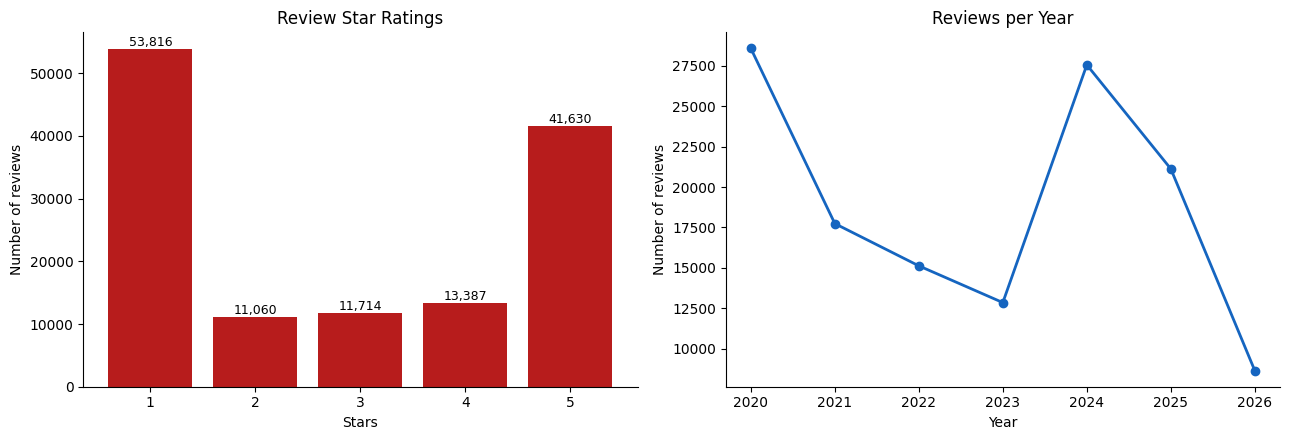

Total reviews: 131,607
Average rating: 2.83
Average review length: 25.4 words


In [5]:
# Overview charts of the dataset.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rc = df_raw["rating"].value_counts().sort_index()
axes[0].bar(rc.index.astype(int).astype(str), rc.values, color="#B71C1C")
for x, y in zip(range(len(rc)), rc.values):
    axes[0].text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Review Star Ratings"); axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Number of reviews"); axes[0].spines[["top","right"]].set_visible(False)

yr = df_raw.dropna(subset=["date"]).copy()
yr["year"] = yr["date"].dt.year
yc = yr["year"].value_counts().sort_index()
axes[1].plot(yc.index.astype(str), yc.values, marker="o", color="#1565C0", linewidth=2)
axes[1].set_title("Reviews per Year"); axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of reviews"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total reviews: {len(df_raw):,}")
print(f"Average rating: {df_raw['rating'].mean():.2f}")
print(f"Average review length: {df_raw['text'].astype(str).str.split().str.len().mean():.1f} words")

## 2. Clean the text

Near-duplicate removal (v2) is order-independent: reviews are grouped into
blocks by their first 20 characters and compared *within* each block with a
vectorized similarity matrix (`rapidfuzz.process.cdist`, all cores). The
previous sliding-window implementation depended on row order and missed
duplicates more than 300 positions apart.

In [6]:
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import emoji
from rapidfuzz import process, fuzz

DetectorFactory.seed = SEED

LOW_INFO = {"good", "bad", "nice", "ok", "wow", "love it", "hate it",
            "very good", "very bad", "awesome", "terrible"}
SPAM_PATTERNS = [r"earn money", r"work from home", r"visit my channel",
                 r"subscribe to", r"check out my", r"promo code",
                 r"free followers", r"telegram", r"whatsapp"]


def detect_lang_safe(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"


def clean_text(text):
    text = str(text).strip().lower()
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\-\'\"]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def is_low_quality(text):
    if not isinstance(text, str):
        return True
    txt = text.strip()
    if len(txt) < 20 or len(txt.split()) < 4:
        return True
    if txt.lower() in LOW_INFO:
        return True
    if re.search(r"(.)\1{5,}", txt):                # elongated character spam
        return True
    return False


def is_spam_like(text):
    txt = text.lower()
    return any(re.search(p, txt) for p in SPAM_PATTERNS)


def remove_near_duplicates(frame, text_col="text_clean", threshold=97):
    """Order-independent near-duplicate removal via blocking + cdist."""
    frame = frame.reset_index(drop=True)
    block = frame[text_col].str[:20]
    drop = set()
    for _, g in frame.groupby(block):
        if len(g) < 2:
            continue
        texts = g[text_col].tolist()
        sim = process.cdist(texts, texts, scorer=fuzz.ratio, workers=-1)
        gidx = g.index.to_numpy()
        for i in range(len(texts)):
            if gidx[i] in drop:
                continue
            dup = np.where(sim[i, i + 1:] >= threshold)[0] + i + 1
            drop.update(gidx[j] for j in dup)
    return frame.drop(index=list(drop)).reset_index(drop=True)

In [7]:
df = df_raw.dropna(subset=["text", "date"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() >= 15].copy()

df["lang"] = df["text"].apply(detect_lang_safe)
df = df[df["lang"] == "en"].copy()
print("After language filter:", len(df))

df["text_clean"] = df["text"].apply(clean_text)

before = len(df)
df = df[~df["text_clean"].apply(is_low_quality)]
df = df[~df["text_clean"].apply(is_spam_like)]
print("Removed low-quality / spam:", before - len(df))

before = len(df)
df = df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)
print("Removed exact duplicates:", before - len(df))

before = len(df)
df = remove_near_duplicates(df, threshold=97)
print("Removed near-duplicates:", before - len(df))

df = df.reset_index(drop=True)
df["review_id"] = df.index
print("Final cleaned reviews:", len(df))

After language filter: 114216
Removed low-quality / spam: 3734
Removed exact duplicates: 491
Removed near-duplicates: 93
Final cleaned reviews: 109898


## 3. Split reviews into short opinions

v2: segmentation runs through `nlp.pipe` with only the components needed for
sentence boundaries, instead of one `nlp(text)` call per review inside a
Python loop.

In [8]:
import spacy

nlp = spacy.load("en_core_web_sm",
                 disable=["tagger", "attribute_ruler", "lemmatizer", "ner"])
MIN_TOKENS = 3
CONTRAST = re.compile(r"\b(?:but|however|although|though)\b", re.I)


def split_doc_into_segments(doc):
    segments = []
    for sent in doc.sents:
        s = sent.text.strip(" ,.-")
        parts = [p.strip(" ,.-") for p in CONTRAST.split(s)]
        good = [p for p in parts if len(p.split()) >= MIN_TOKENS]
        if len(good) >= 2:
            segments.extend(good)        # genuine two-sided opinion -> keep both
        elif len(s.split()) >= MIN_TOKENS:
            segments.append(s)           # otherwise keep the whole sentence
    return segments


def split_review_into_segments(text):
    """Single-text wrapper used by the interactive demo."""
    return split_doc_into_segments(nlp(str(text)))

In [9]:
texts = df["text_clean"].astype(str).tolist()
segment_rows = []
for row, doc in zip(df.itertuples(index=False),
                    nlp.pipe(texts, batch_size=256)):
    for seg_id, seg in enumerate(split_doc_into_segments(doc)):
        segment_rows.append({
            "review_id": row.review_id,
            "segment_id": seg_id,
            "text_clean": seg,
            "rating": row.rating,
            "date": row.date,
        })

segments_df = pd.DataFrame(segment_rows)
print("Total segments:", len(segments_df))
segments_df.head()

Total segments: 262745


,review_id,segment_id,text_clean,rating,date
0,0,0,loved the content and the streaming quality,5,2026-07-07 08:50:22
1,1,0,netflix has a lot of movie that i love to watc...,5,2026-07-07 08:07:00
2,2,0,this app misses on the important things,2,2026-07-07 07:36:35
3,2,1,it's just tedious,2,2026-07-07 07:36:35
4,2,2,for example i'm going for a long flight,2,2026-07-07 07:36:35


## 4. Auto-label reviews with the LLM

Qwen2.5-7B-Instruct labels a sample of segments (the silver corpus). Each
prompt includes the star rating and explicit decision rules. The silver cache
is fingerprinted over model id, prompt, sample size, and seed, so a change in
any of them invalidates the cache instead of silently reusing old labels.

In [10]:
LLM_ID = "Qwen/Qwen2.5-7B-Instruct"
N_LLM = 6000
LLM_BATCH = 16

SWOT_DEFINITION = """Classify an app review segment into SWOT categories.
- Strength: the user PRAISES something (good content, quality, value, ease of use).
- Weakness: an EXISTING problem (bug, crash, error, poor support, bad/removed content).
- Opportunity: a REQUEST for something NEW (add a feature, content, or language).
- Threat: a BUSINESS RISK (price too high, cancellation, competitor comparison, loss of trust).
Rules: any bug/crash is always Weakness; "add/wish/please" a new thing is Opportunity;
churn/price/competitor is Threat."""

FEW_SHOT = """Rating: 5 | "great quality and streaming is fast" -> Strength
Rating: 1 | "app keeps crashing" -> Weakness
Rating: 4 | "should add tamil subtitles" -> Opportunity
Rating: 1 | "cancelling, too expensive" -> Threat
Rating: 2 | "content is poor and boring" -> Weakness
Rating: 1 | "amazon prime is cheaper" -> Threat
Rating: 3 | "clean interface but crashes a lot" -> Strength, Weakness"""

SILVER_FP = fingerprint({"llm": LLM_ID, "prompt": SWOT_DEFINITION + FEW_SHOT,
                         "n": N_LLM, "seed": SEED, "parser": "order-of-appearance-v2"})
SILVER_STATUS = cache_status(LLM_CACHE, SILVER_FP)
NEED_LLM = SILVER_STATUS in ("missing", "stale")

if NEED_LLM:
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    llm_tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
    llm_tokenizer.padding_side = "left"
    if llm_tokenizer.pad_token is None:
        llm_tokenizer.pad_token = llm_tokenizer.eos_token

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)

    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_ID, quantization_config=bnb_config, device_map="auto",
        max_memory={0: "13GiB", 1: "13GiB", "cpu": "24GiB"}, low_cpu_mem_usage=True)
    llm_model.eval()
    print("LLM loaded across:", set(llm_model.hf_device_map.values()))
else:
    print(f"Silver cache usable ({SILVER_STATUS}); skipping LLM load.")

Silver cache usable (legacy); skipping LLM load.


In [11]:
def build_prompt(text, rating):
    r = int(rating) if pd.notna(rating) else 3
    user_prompt = (
        SWOT_DEFINITION + "\n\n" + FEW_SHOT +
        "\n\nReturn ONLY the category names, nothing else.\n\n"
        f'Rating: {r} | "{text}" ->')
    messages = [
        {"role": "system", "content": "You classify app reviews into SWOT categories."},
        {"role": "user", "content": user_prompt},
    ]
    return llm_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)


def parse_labels(response):
    """v2: labels in ORDER OF APPEARANCE in the response, not canonical order.
    The previous version returned SWOT_LABELS order, which silently biased any
    'first label' logic (e.g. the teacher-vs-student comparison) toward Strength."""
    low = response.lower()
    found = [(low.find(lab.lower()), lab) for lab in SWOT_LABELS]
    return [lab for pos, lab in sorted(found) if pos != -1]


def llm_classify_batch(texts, ratings):
    prompts = [build_prompt(str(t), r) for t, r in zip(texts, ratings)]
    enc = llm_tokenizer(prompts, return_tensors="pt", padding=True,
                        truncation=True, max_length=512).to(llm_model.device)
    with torch.no_grad():
        out = llm_model.generate(
            **enc, max_new_tokens=20, do_sample=False,
            pad_token_id=llm_tokenizer.pad_token_id)
    gen = out[:, enc["input_ids"].shape[1]:]
    decoded = llm_tokenizer.batch_decode(gen, skip_special_tokens=True)
    return [parse_labels(d) for d in decoded]

In [12]:
# Sanity check on representative segments (only when the LLM is loaded).
if NEED_LLM:
    sanity_texts = ["good app with lots of movies", "it keeps freezing on my phone",
                    "please add greek subtitles", "too expensive i will cancel"]
    sanity_ratings = [5, 1, 4, 1]
    for t, labs in zip(sanity_texts, llm_classify_batch(sanity_texts, sanity_ratings)):
        print(f"{t!r:45} -> {labs}")
else:
    print("Silver cache in use; LLM sanity check skipped.")

Silver cache in use; LLM sanity check skipped.


## 5. The human gold set (loaded before silver sampling)

The gold set is loaded *before* silver sampling so its segments can be
excluded from the silver pool. Segments of the same source review stay in one
subset (`GroupShuffleSplit`), because sibling segments share vocabulary and a
plain random split would leak the review across train and test.

A calibration slice is carved **out of the training portion** of the gold set.
It is used only to select the prior-shift strength ALPHA; it never enters
training, and the test partition is never touched by any tuning step.

In [13]:
HUMAN_PATH = "/kaggle/input/datasets/anastasiapolitidou/gold-segments/gold_segments.csv"

human_all = pd.read_csv(HUMAN_PATH)
human_all = human_all.rename(columns={"segment_text": "text_clean"})
human_all["manual_swot"] = human_all["manual_swot"].astype(str).str.strip()
human_all = human_all[human_all["manual_swot"].isin(SWOT_LABELS)].reset_index(drop=True)


def norm_text(s):
    return re.sub(r"\s+", " ", str(s).strip().lower())


human_all["parent_key"] = human_all["original_review"].apply(norm_text)

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.45, random_state=SEED)
train_idx, test_idx = next(gss.split(human_all, groups=human_all["parent_key"]))
human_train = human_all.iloc[train_idx].reset_index(drop=True)
human_test = human_all.iloc[test_idx].reset_index(drop=True)

# Calibration slice, grouped by review, carved from the TRAINING side.
gss_c = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
keep_idx, calib_idx = next(gss_c.split(human_train, groups=human_train["parent_key"]))
human_calib = human_train.iloc[calib_idx].reset_index(drop=True)
human_train = human_train.iloc[keep_idx].reset_index(drop=True)

TEST_PARENTS = set(human_test["parent_key"])

assert set(human_train["parent_key"]).isdisjoint(TEST_PARENTS)
assert set(human_calib["parent_key"]).isdisjoint(TEST_PARENTS)
assert set(human_calib["parent_key"]).isdisjoint(set(human_train["parent_key"]))
assert set(human_train["text_clean"]).isdisjoint(set(human_test["text_clean"]))

print(f"Human-labelled train: {len(human_train)} | calib: {len(human_calib)} | test: {len(human_test)}")
print(f"Source reviews -> train: {human_train['parent_key'].nunique()} | "
      f"calib: {human_calib['parent_key'].nunique()} | test: {len(TEST_PARENTS)}")
print("Test-set class distribution:")
print(human_test["manual_swot"].value_counts())

Human-labelled train: 140 | calib: 27 | test: 132
Source reviews -> train: 54 | calib: 14 | test: 56
Test-set class distribution:
manual_swot
Weakness       64
Strength       37
Threat         16
Opportunity    15
Name: count, dtype: int64


In [14]:
from tqdm.auto import tqdm

human_texts = set(human_all["text_clean"].astype(str))
# Exclude the full-review text of every test segment from the silver pool too.
human_parent_texts = set(human_test["original_review"].astype(str))

if not NEED_LLM:
    llm_df = pd.read_csv(LLM_CACHE)
    llm_df["labels"] = llm_df["labels"].apply(
        lambda s: [x for x in str(s).split("|") if x])
    print("Loaded cached silver labels:", len(llm_df))
else:
    llm_pool = segments_df[
        ~segments_df["text_clean"].astype(str).isin(human_texts)
        & ~segments_df["text_clean"].astype(str).isin(human_parent_texts)]
    llm_sample = llm_pool.sample(
        n=min(N_LLM, len(llm_pool)), random_state=SEED).reset_index(drop=True)
    s_texts = llm_sample["text_clean"].astype(str).tolist()
    s_rates = llm_sample["rating"].tolist()

    records = []
    for i in tqdm(range(0, len(s_texts), LLM_BATCH), desc="Annotation"):
        bt, br = s_texts[i:i + LLM_BATCH], s_rates[i:i + LLM_BATCH]
        for t, r, labels in zip(bt, br, llm_classify_batch(bt, br)):
            if labels:
                records.append({"text_clean": t, "rating": r, "labels": labels})

    llm_df = pd.DataFrame(records)
    cache_out = llm_df.copy()
    cache_out["labels"] = cache_out["labels"].apply(lambda L: "|".join(L))
    out_path = "/kaggle/working/silver_labeled.csv"
    cache_out.to_csv(out_path, index=False)
    write_cache_meta(out_path, SILVER_FP)
    print("Silver labels saved to:", out_path)

print("Silver segments:", len(llm_df))
for lab in SWOT_LABELS:
    print(f"  {lab:12}: {llm_df['labels'].apply(lambda L: lab in L).sum()}")

Loaded cached silver labels: 5993
Silver segments: 5993
  Strength    : 1808
  Weakness    : 3069
  Opportunity : 798
  Threat      : 692


In [15]:
if NEED_LLM:
    del llm_model
    gc.collect()
    torch.cuda.empty_cache()
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024 ** 3:.2f} GB")

### Leakage re-checks

The silver pool was filtered before sampling; the asserts below re-confirm the
guarantees after loading (they also protect against a stale silver cache built
under a different split).

In [16]:
assert set(human_test["text_clean"]).isdisjoint(set(llm_df["text_clean"])), \
    "Leakage: a gold test segment appears in the silver set."
assert TEST_PARENTS.isdisjoint(set(llm_df["text_clean"].apply(norm_text))), \
    "Leakage: a gold test parent review appears in the silver set."
print("Leakage checks passed (segment- and review-level).")
print(f"Human train: {len(human_train)} | test: {len(human_test)} | silver: {len(llm_df)}")

Leakage checks passed (segment- and review-level).
Human train: 140 | test: 132 | silver: 5993


## 6. Build the training set

Labels become a four-dimensional multi-hot target. The silver data is split
into a training part and a validation part (used for early stopping and
threshold tuning). The gold test set is never touched here.

The human-labelled training rows are oversampled by `HUMAN_WEIGHT` because the
teacher under-labels the dominant Weakness class relative to human judgment.
Note the documented interaction: this oversampling pulls the *training* prior
toward the *human* prior, which is exactly why the prior-shift search in
Section 10b later selects ALPHA = 0 — the correction is already implicit in
the training mix. `HUMAN_WEIGHT` was selected on the silver validation split
(x1 / x3 / x6 were compared; x6 gave the best macro-F1).

Every row also carries a `primary_label` (single label): the human label for
gold rows, the first label *in order of appearance* for silver rows. The
baselines in Section 12 train on exactly this column, on exactly the same
rows as RoBERTa, so the comparison is fair.

In [17]:
from sklearn.model_selection import train_test_split

HUMAN_WEIGHT = 6


def to_multihot(label_list):
    return [1.0 if lab in label_list else 0.0 for lab in SWOT_LABELS]


llm_df = llm_df.copy()
llm_df["target"] = llm_df["labels"].apply(to_multihot)
llm_df["primary_label"] = llm_df["labels"].apply(lambda L: L[0])

llm_freq = {lab: int(llm_df["labels"].apply(lambda L: lab in L).sum())
            for lab in SWOT_LABELS}


def rarest_label(label_list):
    present = [lab for lab in label_list if lab in llm_freq]
    return min(present, key=lambda l: llm_freq[l]) if present else FALLBACK_LABEL


strat_key = llm_df["labels"].apply(rarest_label)
llm_train, llm_val = train_test_split(
    llm_df, test_size=0.15, random_state=SEED, stratify=strat_key)

human_train = human_train.copy()
human_train["target"] = human_train["manual_swot"].apply(lambda x: to_multihot([x]))
human_train["labels"] = human_train["manual_swot"].apply(lambda x: [x])
human_train["primary_label"] = human_train["manual_swot"]
human_train_weighted = pd.concat([human_train] * HUMAN_WEIGHT, ignore_index=True)

# Additional review-level human labels as extra training data. Many of these
# full reviews are the parents of gold test segments, so leakage is filtered
# at the review level (parent_key); calibration parents are blocked too.
EXTRA_PATH = "/kaggle/input/datasets/anastasiapolitidou/review-swot-annotation-corrected/review_swot_annotation_corrected.csv"
human_extra = pd.read_csv(EXTRA_PATH)
human_extra["manual_swot"] = human_extra["manual_swot"].astype(str).str.strip()
human_extra = human_extra[human_extra["manual_swot"].isin(SWOT_LABELS)].copy()

human_extra["parent_key"] = human_extra["text_clean"].apply(norm_text)
blocked_parents = TEST_PARENTS | set(human_calib["parent_key"])
before_h = len(human_extra)
human_extra = human_extra[~human_extra["parent_key"].isin(blocked_parents)]
human_extra = human_extra[~human_extra["text_clean"].astype(str).isin(
    set(human_test["text_clean"].astype(str))
    | set(human_calib["text_clean"].astype(str)))]
print(f"Dropped {before_h - len(human_extra)} human reviews for review-level leakage.")

human_extra["labels"] = human_extra["manual_swot"].apply(lambda x: [x])
human_extra["target"] = human_extra["manual_swot"].apply(lambda x: to_multihot([x]))
human_extra["primary_label"] = human_extra["manual_swot"]

TRAIN_COLS = ["text_clean", "labels", "target", "primary_label"]
train_df = pd.concat(
    [llm_train[TRAIN_COLS], human_train_weighted[TRAIN_COLS], human_extra[TRAIN_COLS]],
    ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(f"Added {len(human_extra)} human-labelled reviews to training.")
print(f"Train rows: {len(train_df)} | silver val: {len(llm_val)}")
print("Training class counts:")
for lab in SWOT_LABELS:
    print(f"  {lab:12}: {train_df['labels'].apply(lambda L: lab in L).sum()}")

Dropped 70 human reviews for review-level leakage.
Added 230 human-labelled reviews to training.
Train rows: 6164 | silver val: 899
Training class counts:
  Strength    : 1803
  Weakness    : 3104
  Opportunity : 864
  Threat      : 708


## 7. Tokenize the text

v2: dynamic padding via `DataCollatorWithPadding` instead of padding every
sequence to `max_length` — same results, meaningfully faster on short reviews.

In [18]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback, set_seed)
from datasets import Dataset

set_seed(SEED)   # covers python, numpy, torch and CUDA for the training run

CLASSIFIER_ID = "roberta-large"
classifier_tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_ID)


def make_dataset(frame):
    ds = Dataset.from_dict({
        "text": frame["text_clean"].astype(str).tolist(),
        "labels": [list(map(float, t)) for t in frame["target"].tolist()],
    })
    ds = ds.map(lambda b: classifier_tokenizer(b["text"], truncation=True, max_length=96),
                batched=True)
    return ds.remove_columns(["text"])


train_ds = make_dataset(train_df)
val_ds = make_dataset(llm_val)
data_collator = DataCollatorWithPadding(tokenizer=classifier_tokenizer)
print("Datasets ready.")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6164 [00:00<?, ? examples/s]

Map:   0%|          | 0/899 [00:00<?, ? examples/s]

Datasets ready.


## 8. Train the classifier

One RoBERTa-large, binary cross-entropy over four sigmoid outputs
(`problem_type="multi_label_classification"`), at most 4 epochs with early
stopping on the silver-validation macro-F1, best checkpoint kept. The 0.5
threshold inside `compute_metrics` serves model selection only; deployment
thresholds are tuned separately in Section 10.

In [19]:
from sklearn.metrics import f1_score, accuracy_score


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)
    return {
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "subset_acc": accuracy_score(labels, preds),
    }


def new_classifier():
    return AutoModelForSequenceClassification.from_pretrained(
        CLASSIFIER_ID, num_labels=4, problem_type="multi_label_classification",
        id2label={i: l for i, l in enumerate(SWOT_LABELS)},
        label2id={l: i for i, l in enumerate(SWOT_LABELS)})


train_args = TrainingArguments(
    output_dir="/kaggle/working/swot_model", num_train_epochs=4,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.1,
    lr_scheduler_type="cosine", eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    greater_is_better=True, report_to="none", seed=SEED,
    fp16=torch.cuda.is_available(), dataloader_pin_memory=False,
    save_total_limit=1, save_only_model=True)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [20]:
classifier_model = new_classifier()
trainer = Trainer(
    model=classifier_model, args=train_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer.train()
print("Training complete.")

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along 

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Subset Acc
1,No log,0.481582,0.807507,0.762631,0.739711
2,No log,0.478611,0.801314,0.769650,0.730812
3,0.500788,0.463640,0.838470,0.800039,0.784205
4,0.500788,0.506883,0.839050,0.806226,0.788654


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training complete.


In [21]:
@torch.inference_mode()
def predict_proba(texts, batch_size=128):
    """Sigmoid probabilities of the single fine-tuned classifier."""
    classifier_model.eval()
    device = classifier_model.device
    out = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i + batch_size]]
        enc = classifier_tokenizer(batch, truncation=True, padding=True,
                                   max_length=96, return_tensors="pt").to(device)
        with torch.autocast("cuda", enabled=device.type == "cuda"):
            logits = classifier_model(**enc).logits
        out.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.vstack(out)

## 9. Save the model

In [22]:
classifier_model.save_pretrained("/kaggle/working/netflix-swot-model")
classifier_tokenizer.save_pretrained("/kaggle/working/netflix-swot-model")
print("Model saved to /kaggle/working/netflix-swot-model")

# Optional Hugging Face upload; no-op when HF_TOKEN is absent.
HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    classifier_model.push_to_hub("apolitidou/netflix-swot-classifier")
    classifier_tokenizer.push_to_hub("apolitidou/netflix-swot-classifier")
    print("Uploaded to Hugging Face Hub.")
else:
    print("HF_TOKEN not set; skipping upload.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/netflix-swot-model
HF_TOKEN not set; skipping upload.


## 10. Tune the thresholds

Per-class thresholds maximize per-class F1 on the silver validation split,
then are frozen. Threshold selection never sees the gold test set.

In [23]:
val_probs = predict_proba(llm_val["text_clean"].tolist())
val_true = np.array(llm_val["target"].tolist()).astype(int)

thresholds = {}
for c, cat in enumerate(SWOT_LABELS):
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.20, 0.71, 0.05):
        pred = (val_probs[:, c] >= t).astype(int)
        f1 = f1_score(val_true[:, c], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, round(float(t), 2)
    thresholds[cat] = best_t

thr_vec = np.array([thresholds[l] for l in SWOT_LABELS])
print("Tuned thresholds:", thresholds)

Tuned thresholds: {'Strength': 0.55, 'Weakness': 0.3, 'Opportunity': 0.45, 'Threat': 0.2}


## 10b. Prior-shift correction (Saerens et al., 2002)

The predicted probabilities can be reweighted toward the human class prior.
The strength ALPHA is selected on the **human calibration slice** — carved
from the training side of the gold set and excluded from training — so the
gold test set is never used for tuning. With only 27 calibration segments the
selection is noisy; ALPHA is therefore reported as a robustness check, and the
selected value (0.0, i.e. no correction) is consistent with the fact that the
HUMAN_WEIGHT oversampling in Section 6 already aligns the training prior with
the human prior.

In [24]:
train_prior = np.array([train_df["labels"].apply(lambda L: lab in L).mean()
                        for lab in SWOT_LABELS])
human_prior = np.array([(human_train["manual_swot"] == lab).mean() for lab in SWOT_LABELS])
prior_ratio = human_prior / np.clip(train_prior, 1e-6, None)

calib_probs = predict_proba(human_calib["text_clean"].tolist())
calib_true = human_calib["manual_swot"].tolist()
calib_yt = np.array([to_multihot([x]) for x in calib_true]).astype(int)


def _balanced_objective(p, true_labels, yt):
    idx = p.argmax(axis=1)
    pred = [SWOT_LABELS[i] for i in idx]
    yp = np.zeros_like(yt); yp[np.arange(len(idx)), idx] = 1
    a = accuracy_score(true_labels, pred)
    m = f1_score(yt, yp, average="macro", zero_division=0)
    return 0.5 * a + 0.5 * m


best_alpha, best_obj = 0.0, -1.0
for a in np.arange(0.0, 1.01, 0.1):
    obj = _balanced_objective(calib_probs * (prior_ratio ** a), calib_true, calib_yt)
    if obj > best_obj:
        best_obj, best_alpha = obj, round(float(a), 1)

ALPHA = best_alpha
print(f"Selected ALPHA (on the human calibration slice): {ALPHA}")
print("Prior ratio:", {l: round(float(r), 2) for l, r in zip(SWOT_LABELS, prior_ratio)})

Selected ALPHA (on the human calibration slice): 0.0
Prior ratio: {'Strength': 0.88, 'Weakness': 0.95, 'Opportunity': 1.22, 'Threat': 0.81}


## 11. Test the model

Two decision rules are evaluated on the quarantined gold test set:

1. **Argmax rule** — one label per segment; comparable to the single-label
   gold annotation and to the baselines.
2. **Production rule** (v2) — the exact rule that labels the corpus in
   Section 13: per-class thresholds, `Unclassified` when nothing passes.
   Reporting it here closes the evaluation/deployment gap: the rule that
   produces the SWOT matrix is now itself validated on human data.

In [25]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

probs_test = predict_proba(human_test["text_clean"].tolist())
probs_test = probs_test * (prior_ratio ** ALPHA)      # no-op when ALPHA = 0
true_label = human_test["manual_swot"].tolist()
y_true = np.array([to_multihot([x]) for x in true_label]).astype(int)

pred_idx = probs_test.argmax(axis=1)
pred_label = [SWOT_LABELS[i] for i in pred_idx]
y_pred = np.zeros_like(y_true)
y_pred[np.arange(len(pred_idx)), pred_idx] = 1

acc = accuracy_score(true_label, pred_label)
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("=" * 64)
print("TEST RESULTS — argmax rule (one label per segment)")
print("=" * 64)
print(f"Overall accuracy : {acc:.4f}  ({acc * 100:.1f}%)")
print(f"Micro F1-score   : {micro_f1:.4f}")
print(f"Macro F1-score   : {macro_f1:.4f}")
print("-" * 64)
print(classification_report(true_label, pred_label,
                            labels=SWOT_LABELS, zero_division=0))

TEST RESULTS — argmax rule (one label per segment)
Overall accuracy : 0.8409  (84.1%)
Micro F1-score   : 0.8409
Macro F1-score   : 0.7982
----------------------------------------------------------------
              precision    recall  f1-score   support

    Strength       0.97      0.89      0.93        37
    Weakness       0.87      0.86      0.87        64
 Opportunity       0.71      0.80      0.75        15
      Threat       0.61      0.69      0.65        16

    accuracy                           0.84       132
   macro avg       0.79      0.81      0.80       132
weighted avg       0.85      0.84      0.84       132



In [26]:
# Production rule on the same gold test set: thresholds + Unclassified.
prod_sets = []
for p in probs_test:
    accepted = [SWOT_LABELS[i] for i in range(4) if p[i] >= thr_vec[i]]
    prod_sets.append(accepted)

n_unc = sum(1 for s in prod_sets if not s)
gold_in_set = np.mean([t in s for t, s in zip(true_label, prod_sets)])
avg_card = np.mean([len(s) for s in prod_sets if s]) if len(prod_sets) > n_unc else 0.0
top1_prod = [max(s, key=lambda l: probs_test[k, SWOT_LABELS.index(l)]) if s else UNCLASSIFIED
             for k, s in enumerate(prod_sets)]
acc_prod_top1 = np.mean([p == t for p, t in zip(top1_prod, true_label)])

print("PRODUCTION RULE on the gold test set")
print(f"  Gold label contained in predicted set : {gold_in_set:.3f}")
print(f"  Avg labels per classified segment     : {avg_card:.2f}")
print(f"  Unclassified segments                 : {n_unc}/{len(prod_sets)}")
print(f"  Top-1 accuracy (Unclassified = wrong) : {acc_prod_top1:.3f}")

PRODUCTION RULE on the gold test set
  Gold label contained in predicted set : 0.871
  Avg labels per classified segment     : 1.08
  Unclassified segments                 : 1/132
  Top-1 accuracy (Unclassified = wrong) : 0.841


In [27]:
prec, rec, f1c, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(4), zero_division=0)

print("Per-class metrics on the gold test set (argmax rule)")
print(f"{'Class':12} {'Precision':>10} {'Recall':>10} {'F1':>10} "
      f"{'Acc(incl.TN)':>13} {'Support':>9}")
for i, lab in enumerate(SWOT_LABELS):
    cls_acc = (y_true[:, i] == y_pred[:, i]).mean()
    print(f"{lab:12} {prec[i]:>10.3f} {rec[i]:>10.3f} {f1c[i]:>10.3f} "
          f"{cls_acc * 100:>12.1f}% {int(support[i]):>9}")

Per-class metrics on the gold test set (argmax rule)
Class         Precision     Recall         F1  Acc(incl.TN)   Support
Strength          0.971      0.892      0.930         96.2%        37
Weakness          0.873      0.859      0.866         87.1%        64
Opportunity       0.706      0.800      0.750         93.9%        15
Threat            0.611      0.688      0.647         90.9%        16


## 12. Compare with simple baselines

v2: both baselines train on **exactly the same rows** as RoBERTa
(`train_df`, using `primary_label`), not on the full silver set — otherwise
the comparison confounds architecture with training data.

In [28]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

majority = DummyClassifier(strategy="most_frequent").fit(
    train_df["text_clean"], train_df["primary_label"])
acc_majority = accuracy_score(true_label, majority.predict(human_test["text_clean"]))

tfidf_lr = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000, class_weight="balanced"))
tfidf_lr.fit(train_df["text_clean"], train_df["primary_label"])
acc_tfidf = accuracy_score(true_label, tfidf_lr.predict(human_test["text_clean"]))

print(f"Baseline comparison ({len(human_test)} gold segments, identical training rows)")
print(f"  Majority class        : {acc_majority:.3f}")
print(f"  TF-IDF + LogReg       : {acc_tfidf:.3f}")
print(f"  Fine-tuned RoBERTa    : {acc:.3f}")

rng = np.random.RandomState(SEED)
boot = []
for _ in range(2000):
    idx = rng.choice(len(true_label), len(true_label), replace=True)
    boot.append(accuracy_score([true_label[i] for i in idx],
                               [pred_label[i] for i in idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"  95% bootstrap CI      : [{lo:.3f}, {hi:.3f}]")

Baseline comparison (132 gold segments, identical training rows)
  Majority class        : 0.485
  TF-IDF + LogReg       : 0.720
  Fine-tuned RoBERTa    : 0.841
  95% bootstrap CI      : [0.773, 0.902]


In [29]:
# Statistical significance vs the TF-IDF baseline.
from statsmodels.stats.contingency_tables import mcnemar

model_pred = list(pred_label)
tfidf_pred = list(tfidf_lr.predict(human_test["text_clean"]))
truth = list(true_label)

model_ok = np.array([p == t for p, t in zip(model_pred, truth)])
tfidf_ok = np.array([p == t for p, t in zip(tfidf_pred, truth)])

b = int(np.sum(model_ok & ~tfidf_ok))
c = int(np.sum(~model_ok & tfidf_ok))
table = [[int(np.sum(model_ok & tfidf_ok)), b],
         [c, int(np.sum(~model_ok & ~tfidf_ok))]]
res = mcnemar(table, exact=False, correction=True)
print("McNemar test (model vs TF-IDF baseline)")
print(f"  model-only correct: {b} | baseline-only correct: {c}")
print(f"  statistic = {res.statistic:.3f} | p-value = {res.pvalue:.4f}")
print(f"  {'Significant (p<0.05)' if res.pvalue < 0.05 else 'Not significant (p>=0.05)'}")

rng = np.random.RandomState(SEED)
n = len(truth); diffs = []
for _ in range(5000):
    idx = rng.choice(n, n, replace=True)
    diffs.append(model_ok[idx].mean() - tfidf_ok[idx].mean())
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"\nAccuracy difference (model - baseline): {np.mean(diffs):.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
print(f"  {'Significant' if lo > 0 else 'Not significant'} (CI {'excludes' if lo > 0 else 'includes'} 0)")

McNemar test (model vs TF-IDF baseline)
  model-only correct: 22 | baseline-only correct: 6
  statistic = 8.036 | p-value = 0.0046
  Significant (p<0.05)

Accuracy difference (model - baseline): 0.121  95% CI [0.045, 0.197]
  Significant (CI excludes 0)


## 12b. Extra checks: bootstrap CIs, confusion matrix, error analysis

In [30]:
rng = np.random.RandomState(SEED)
n = len(true_label)
true_arr = np.array(true_label)
pred_arr = np.array(pred_label)
yt = np.array([to_multihot([x]) for x in true_label]).astype(int)
yp = np.array([to_multihot([x]) for x in pred_label]).astype(int)

B = 2000
boot = {"accuracy": [], "micro_f1": [], "macro_f1": []}
boot_cls = {lab: [] for lab in SWOT_LABELS}
for _ in range(B):
    idx = rng.choice(n, n, replace=True)
    boot["accuracy"].append(accuracy_score(true_arr[idx], pred_arr[idx]))
    boot["micro_f1"].append(f1_score(yt[idx], yp[idx], average="micro", zero_division=0))
    boot["macro_f1"].append(f1_score(yt[idx], yp[idx], average="macro", zero_division=0))
    for ci_, lab in enumerate(SWOT_LABELS):
        boot_cls[lab].append(f1_score(yt[idx, ci_], yp[idx, ci_], zero_division=0))


def ci(vals):
    return np.percentile(vals, [2.5, 97.5])


print("Metric         point   95% CI")
for k in ["accuracy", "micro_f1", "macro_f1"]:
    lo, hi = ci(boot[k])
    print(f"{k:12}  {np.mean(boot[k]):.3f}  [{lo:.3f}, {hi:.3f}]")
print("\nPer-class F1 (95% CI) — note the width on minority classes:")
for lab in SWOT_LABELS:
    lo, hi = ci(boot_cls[lab])
    print(f"  {lab:12} {np.mean(boot_cls[lab]):.3f}  [{lo:.3f}, {hi:.3f}]")

Metric         point   95% CI
accuracy      0.841  [0.773, 0.902]
micro_f1      0.841  [0.773, 0.902]
macro_f1      0.794  [0.710, 0.871]

Per-class F1 (95% CI) — note the width on minority classes:
  Strength     0.929  [0.862, 0.985]
  Weakness     0.865  [0.793, 0.923]
  Opportunity  0.743  [0.545, 0.897]
  Threat       0.639  [0.424, 0.818]


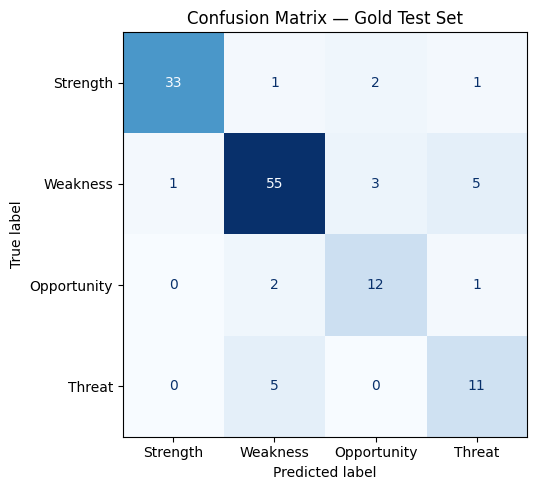

Row-normalised (recall per true class):
true/pred        Strength     Weakness  Opportunity       Threat
Strength             0.89         0.03         0.05         0.03
Weakness             0.02         0.86         0.05         0.08
Opportunity          0.00         0.13         0.80         0.07
Threat               0.00         0.31         0.00         0.69


In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_label, pred_label, labels=SWOT_LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=SWOT_LABELS).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix — Gold Test Set")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Row-normalised (recall per true class):")
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
print(f"{'true/pred':12}" + "".join(f"{l:>13}" for l in SWOT_LABELS))
for i, lab in enumerate(SWOT_LABELS):
    print(f"{lab:12}" + "".join(f"{cm_norm[i, j]:>13.2f}" for j in range(len(SWOT_LABELS))))

In [32]:
# Qualitative error analysis: misclassified segments with model confidence.
err_rows = []
for k in range(len(human_test)):
    if true_label[k] != pred_label[k]:
        err_rows.append({
            "text": human_test["text_clean"].iloc[k][:90],
            "true": true_label[k],
            "predicted": pred_label[k],
            "p_true": round(float(probs_test[k, SWOT_LABELS.index(true_label[k])]), 2),
            "p_pred": round(float(probs_test[k, SWOT_LABELS.index(pred_label[k])]), 2),
        })

errors_df = pd.DataFrame(err_rows)
print(f"Total misclassified: {len(errors_df)} / {len(human_test)}")
print("\nMost common confusions (true -> predicted):")
print((errors_df["true"] + " -> " + errors_df["predicted"]).value_counts().head(8))
print("\nSample of misclassified segments (low p_true = likely ambiguous or label noise):")
errors_df.sort_values("p_true").head(15)

Total misclassified: 21 / 132

Most common confusions (true -> predicted):
Weakness -> Threat         5
Threat -> Weakness         5
Weakness -> Opportunity    3
Strength -> Opportunity    2
Opportunity -> Weakness    2
Weakness -> Strength       1
Strength -> Weakness       1
Opportunity -> Threat      1
Name: count, dtype: int64

Sample of misclassified segments (low p_true = likely ambiguous or label noise):


,text,true,predicted,p_true,p_pred
3,last month on this app,Threat,Weakness,0.00,0.94
11,i just wish it could accommodate other phone b...,Strength,Opportunity,0.01,0.99
5,"this app sucks, bye netflix",Threat,Weakness,0.02,0.99
2,"not enough options for tv series or movies, at...",Weakness,Opportunity,0.02,0.99
10,because all movie old for users,Opportunity,Weakness,0.02,0.99
17,from last 15 days i want to sign in with netflix,Weakness,Opportunity,0.02,0.98
6,"i don't know why ratings are only 3.9 , i am d...",Strength,Weakness,0.03,0.96
4,i can cast other apps,Weakness,Threat,0.03,0.68
9,use to be better,Threat,Weakness,0.04,0.95
18,i can even get premium games too,Strength,Threat,0.05,0.96


## 12c. Teacher vs student

The Qwen teacher runs few-shot on the identical gold test segments. v2: the
prediction cache is fingerprinted over model, prompt, parser version and the
test-set contents, so the fixed `parse_labels` forces a rebuild instead of
silently reloading predictions produced by the biased parser.

In [33]:
LLM_PRED_CACHE = "/kaggle/working/llm_test_pred.csv"
LLMTEST_FP = fingerprint({"llm": LLM_ID, "prompt": SWOT_DEFINITION + FEW_SHOT,
                          "parser": "order-of-appearance-v2",
                          "test": sorted(human_test["text_clean"].astype(str))})

llm_test_pred = None
if cache_status(LLM_PRED_CACHE, LLMTEST_FP) == "valid":
    _tc = pd.read_csv(LLM_PRED_CACHE).drop_duplicates("text_clean").set_index("text_clean")
    if human_test["text_clean"].isin(_tc.index).all():
        llm_test_pred = _tc.loc[human_test["text_clean"], "pred"].tolist()
        print("Loaded cached teacher predictions.")

if llm_test_pred is None:
    # Free training memory and move the classifier to CPU so Qwen fits on GPU.
    if "trainer" in dir():
        del trainer
    classifier_model.to("cpu")
    gc.collect(); torch.cuda.empty_cache()

    if "llm_model" not in dir():
        from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
        llm_tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
        llm_tokenizer.padding_side = "left"
        if llm_tokenizer.pad_token is None:
            llm_tokenizer.pad_token = llm_tokenizer.eos_token
        _bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                                  bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)
        llm_model = AutoModelForCausalLM.from_pretrained(
            LLM_ID, quantization_config=_bnb, device_map="auto",
            max_memory={0: "13GiB", 1: "13GiB", "cpu": "24GiB"}, low_cpu_mem_usage=True)
        llm_model.eval()
        print("Teacher reloaded for gold-set evaluation.")

    from tqdm.auto import tqdm
    g_texts = human_test["text_clean"].astype(str).tolist()
    g_rates = (human_test["rating"].tolist() if "rating" in human_test.columns
               else [3] * len(g_texts))
    llm_test_pred = []
    for i in tqdm(range(0, len(g_texts), 16), desc="Teacher on gold set"):
        for labs in llm_classify_batch(g_texts[i:i + 16], g_rates[i:i + 16]):
            llm_test_pred.append(labs[0] if labs else FALLBACK_LABEL)
    pd.DataFrame({"text_clean": human_test["text_clean"], "pred": llm_test_pred}).to_csv(
        LLM_PRED_CACHE, index=False)
    write_cache_meta(LLM_PRED_CACHE, LLMTEST_FP)

    del llm_model
    gc.collect(); torch.cuda.empty_cache()
    if torch.cuda.is_available():
        classifier_model.to("cuda")

t_true = human_test["manual_swot"].tolist()
t_acc = accuracy_score(t_true, llm_test_pred)
t_yt = np.array([[1 if t == l else 0 for l in SWOT_LABELS] for t in t_true])
t_yp = np.array([[1 if p == l else 0 for l in SWOT_LABELS] for p in llm_test_pred])
print("=" * 60)
print("TEACHER (Qwen2.5-7B few-shot) vs STUDENT (fine-tuned RoBERTa)")
print("=" * 60)
print(f"{'':22}{'Accuracy':>12}{'Macro-F1':>12}")
print(f"{'Teacher (Qwen)':22}{t_acc:>12.3f}"
      f"{f1_score(t_yt, t_yp, average='macro', zero_division=0):>12.3f}")
print(f"{'Student (RoBERTa)':22}{acc:>12.3f}{macro_f1:>12.3f}")
print("-" * 60)
print("Teacher per-class report:")
print(classification_report(t_true, llm_test_pred, labels=SWOT_LABELS, zero_division=0))

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Teacher reloaded for gold-set evaluation.


Teacher on gold set:   0%|          | 0/9 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEACHER (Qwen2.5-7B few-shot) vs STUDENT (fine-tuned RoBERTa)
                          Accuracy    Macro-F1
Teacher (Qwen)               0.780       0.728
Student (RoBERTa)            0.841       0.798
------------------------------------------------------------
Teacher per-class report:
              precision    recall  f1-score   support

    Strength       0.82      0.97      0.89        37
    Weakness       0.87      0.73      0.80        64
 Opportunity       0.58      0.73      0.65        15
      Threat       0.60      0.56      0.58        16

    accuracy                           0.78       132
   macro avg       0.72      0.75      0.73       132
weighted avg       0.79      0.78      0.78       132



## 13. Label the full corpus

v2: fully vectorized (no `iterrows` over 262k segments, no shadowing of the
test-set `probs`), segments that pass no threshold become `Unclassified`
instead of being forced into Weakness, and classifier **coverage** is reported
— the share of forced defaults previously contaminated the Weakness quadrant
and its headline share. The cache is fingerprinted over classifier, thresholds
and silver provenance, so retraining invalidates it.

In [34]:
CORPUS_FP = fingerprint({"clf": CLASSIFIER_ID, "thr": thresholds, "alpha": ALPHA,
                         "silver": SILVER_FP, "rule": "unclassified-v2"})
_persistent_corpus = "/kaggle/input/datasets/anastasiapolitidou/corpus-classified/corpus_classified.csv"
CORPUS_CACHE = (_persistent_corpus if os.path.exists(_persistent_corpus)
                else "/kaggle/working/corpus_classified.csv")

if cache_status(CORPUS_CACHE, CORPUS_FP) == "valid":
    df_swot = pd.read_csv(CORPUS_CACHE)
    df_swot["date"] = pd.to_datetime(df_swot["date"], errors="coerce")
    print("Loaded cached corpus classification:", len(df_swot))
else:
    segments_reset = segments_df.reset_index(drop=True)
    p_all = predict_proba(segments_reset["text_clean"].astype(str).tolist(), batch_size=256)
    p_all = p_all * (prior_ratio ** ALPHA)
    acc_mask = p_all >= thr_vec                        # (n, 4)

    frames = []
    for c, lab in enumerate(SWOT_LABELS):
        idx = np.where(acc_mask[:, c])[0]
        f = segments_reset.iloc[idx].copy()
        f["swot_category"] = lab
        f["swot_confidence"] = p_all[idx, c]
        frames.append(f)
    unc_idx = np.where(~acc_mask.any(axis=1))[0]
    unc = segments_reset.iloc[unc_idx].copy()
    unc["swot_category"] = UNCLASSIFIED
    unc["swot_confidence"] = p_all[unc_idx].max(axis=1)
    frames.append(unc)

    df_swot = pd.concat(frames, ignore_index=True)
    out_path = "/kaggle/working/corpus_classified.csv"
    df_swot.to_csv(out_path, index=False)
    write_cache_meta(out_path, CORPUS_FP)

CLASSIFIED = df_swot[df_swot["swot_category"] != UNCLASSIFIED].copy()
coverage = len(CLASSIFIED) and df_swot["review_id"].nunique() and \
    (df_swot["swot_category"] != UNCLASSIFIED).mean()
print(f"Total segment-label pairs : {len(df_swot)}")
print(f"Classifier coverage       : {coverage:.1%} "
      f"({(df_swot['swot_category'] == UNCLASSIFIED).sum()} unclassified rows)")
print(df_swot["swot_category"].value_counts())

Total segment-label pairs : 288965
Classifier coverage       : 99.6% (1255 unclassified rows)
swot_category
Weakness        142261
Strength         72116
Threat           37018
Opportunity      36315
Unclassified      1255
Name: count, dtype: int64


## 14. Topics per SWOT group (BERTopic)

v2 fixes in this stage: (a) the dataframe is filtered *before* modelling and
alignment is asserted, removing the latent `dropna`/`iloc` misalignment;
(b) category embeddings are computed once, passed to BERTopic, and reused for
evidence tables and quote selection instead of being re-encoded; (c) documents
are pre-lemmatized in one `nlp.pipe` pass **with the POS tagger enabled**
(the rule-based lemmatizer needs POS tags — the previous tokenizer disabled
the tagger and silently degraded every lemma); clustering runs on raw-text
embeddings while c-TF-IDF runs on the clean lemmatized text.

In [35]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Free the GPU for sentence-transformers; the classifier returns in Section 18.
classifier_model.to("cpu")
gc.collect(); torch.cuda.empty_cache()

embedding_model = SentenceTransformer("all-mpnet-base-v2")

DOMAIN_STOPWORDS = {
    "netflix", "app", "show", "shows", "movie", "movies", "watch", "watching",
    "series", "phone", "tv", "episode", "season", "seasons", "video", "stream",
    "streaming", "content",
}
STOP_LIST = sorted(ENGLISH_STOP_WORDS | DOMAIN_STOPWORDS)

# POS tagger stays ENABLED: en_core_web_sm's rule lemmatizer requires it.
_lemma_nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


def lemmatize_batch(texts, batch_size=512):
    out = []
    for doc in _lemma_nlp.pipe(texts, batch_size=batch_size):
        out.append(" ".join(t.lemma_.lower() for t in doc
                            if t.is_alpha and not t.is_stop and len(t.lemma_) > 2))
    return out

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [36]:
def build_topics(category, min_topic_size=15):
    cat_df = CLASSIFIED[(CLASSIFIED["swot_category"] == category)
                        & CLASSIFIED["text_clean"].notna()].reset_index(drop=True)
    docs_raw = cat_df["text_clean"].astype(str).tolist()
    print(f"{category}: {len(docs_raw)} segments")
    if len(docs_raw) < 30:
        cat_df["topic_id"] = 0
        return {"df": cat_df, "model": None, "emb": None, "docs_lemma": docs_raw}

    docs_lemma = lemmatize_batch(docs_raw)
    emb = embedding_model.encode(docs_raw, batch_size=256, show_progress_bar=True,
                                 normalize_embeddings=True).astype(np.float32)

    eff = min(min_topic_size, max(5, len(docs_raw) // 20))
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                        metric="cosine", random_state=SEED),
        hdbscan_model=HDBSCAN(min_cluster_size=eff, min_samples=5,
                              metric="euclidean", cluster_selection_method="eom",
                              prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=STOP_LIST,
                                         ngram_range=(1, 2), min_df=5),
        representation_model={"Main": KeyBERTInspired(),
                              "MMR": MaximalMarginalRelevance(diversity=0.5)},
        top_n_words=10, calculate_probabilities=False, verbose=False)

    # Clustering on raw-text embeddings; c-TF-IDF on lemmatized documents.
    topics, _ = topic_model.fit_transform(docs_lemma, embeddings=emb)
    assert len(topics) == len(cat_df), "topic/dataframe misalignment"
    cat_df["topic_id"] = topics
    return {"df": cat_df, "model": topic_model, "emb": emb, "docs_lemma": docs_lemma}


topic_data = {c: build_topics(c) for c in SWOT_LABELS}
topic_models = {c: topic_data[c]["model"] for c in SWOT_LABELS}   # v2: explicitly defined

Strength: 72116 segments


Batches:   0%|          | 0/282 [00:00<?, ?it/s]

Weakness: 142261 segments


Batches:   0%|          | 0/556 [00:00<?, ?it/s]

Opportunity: 36315 segments


Batches:   0%|          | 0/142 [00:00<?, ?it/s]

Threat: 37018 segments


Batches:   0%|          | 0/145 [00:00<?, ?it/s]

### Topic-model quality (c_v coherence and diversity)

v2: this cell previously referenced an undefined `topic_models` dict behind a
`dir()` guard and silently produced an empty table. It now runs, and the
coherence texts use the **same lemmatized representation** as the topic
vectorizer — computing c_v on raw tokens against lemmatized topic words would
systematically underestimate coherence.

In [38]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


def topic_quality(cat):
    tm = topic_models.get(cat)
    if tm is None:
        return None

    docs = [d.split() for d in topic_data[cat]["docs_lemma"] if d.split()]
    if len(docs) < 5:
        return None
    dic = Dictionary(docs)
    vocab = dic.token2id

    info = tm.get_topic_info()
    info = info[info["Topic"] != -1]
    topics_words = []
    for t in info["Topic"]:
        toks = []
        for w, _ in tm.get_topic(t):
            for part in str(w).lower().split():        # split any bigrams
                if part in vocab and part not in toks:
                    toks.append(part)
        if len(toks) >= 3:
            topics_words.append(toks[:10])

    if len(topics_words) < 2:
        return None

    cm = CoherenceModel(topics=topics_words, texts=docs,
                        dictionary=dic, coherence="c_v")
    coherence = cm.get_coherence()
    all_words = [w for tw in topics_words for w in tw]
    diversity = len(set(all_words)) / len(all_words)
    return {"category": cat, "n_topics": len(topics_words),
            "coherence_cv": round(coherence, 3), "diversity": round(diversity, 3)}


rows = []
for cat in SWOT_LABELS:
    try:
        q = topic_quality(cat)
    except Exception as e:
        print(f"  coherence skipped for {cat}: {type(e).__name__}: {e}")
        q = None
    if q:
        rows.append(q)

quality_df = pd.DataFrame(rows)
print("BERTopic quality per category (c_v: higher = better, ~0.5+ is good):")
if len(quality_df):
    display(quality_df)
else:
    print("  no category had >=2 scorable topics")
quality_df.to_csv("/kaggle/working/topic_quality.csv", index=False)

BERTopic quality per category (c_v: higher = better, ~0.5+ is good):


,category,n_topics,coherence_cv,diversity
0,Strength,796,0.364,0.165
1,Weakness,1279,0.456,0.152
2,Opportunity,372,0.414,0.244
3,Threat,358,0.410,0.189


## 15. Turn topics into evidence tables and insights

Evidence tables reuse the stored category embeddings (no re-encoding).
Representative quotes are selected with **MMR** so the LLM sees diverse
evidence instead of six near-identical nearest-centroid sentences. Each topic
also gets a **trend** flag (rising / stable / falling), comparing its share of
mentions after the corpus median date against the category's own baseline.
Note: `coherence` here is the embedding-centroid cosine compactness used for
*filtering*; it is distinct from the c_v metric reported above.

In [39]:
MIN_TOPIC_MENTIONS = 25
MIN_TOPIC_COHERENCE = 0.25

SPLIT_DATE = pd.to_datetime(CLASSIFIED["date"], errors="coerce").median()
CAT_RECENT_SHARE = {
    c: (pd.to_datetime(CLASSIFIED.loc[CLASSIFIED["swot_category"] == c, "date"],
                       errors="coerce") >= SPLIT_DATE).mean()
    for c in SWOT_LABELS}


def topic_trend(df_t, cat_share):
    d = pd.to_datetime(df_t["date"], errors="coerce").dropna()
    if len(d) < 10:
        return "STABLE"
    recent = (d >= SPLIT_DATE).mean()
    if recent >= cat_share + 0.10:
        return "RISING"
    if recent <= cat_share - 0.10:
        return "FALLING"
    return "STABLE"


def mmr_quotes(texts, emb, k=6, diversity=0.4, pool=50):
    centroid = emb.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-9)
    sims = emb @ centroid
    cand = list(np.argsort(-sims)[:pool])
    selected = [cand[0]]
    while len(selected) < min(k * 2, len(cand)):
        rest = [c for c in cand if c not in selected]
        if not rest:
            break
        scores = [((1 - diversity) * sims[c]
                   - diversity * max(float(emb[c] @ emb[s]) for s in selected), c)
                  for c in rest]
        selected.append(max(scores)[1])
    picked = [texts[i].strip() for i in selected if len(texts[i].split()) >= 5][:k]
    return picked or [texts[cand[0]]]


def topic_evidence_table(bundle, category):
    cat_df, emb, model = bundle["df"], bundle["emb"], bundle["model"]
    cat_share = CAT_RECENT_SHARE[category]
    rows = []
    for tid in sorted(cat_df["topic_id"].unique()):
        if tid == -1:
            continue
        mask = (cat_df["topic_id"] == tid).to_numpy()
        df_t = cat_df[mask]
        mentions = df_t["review_id"].nunique()
        if mentions < MIN_TOPIC_MENTIONS:
            continue
        emb_t = emb[mask] if emb is not None else None
        if emb_t is not None:
            centroid = emb_t.mean(axis=0)
            centroid = centroid / (np.linalg.norm(centroid) + 1e-9)
            compactness = float((emb_t @ centroid).mean())
            if compactness < MIN_TOPIC_COHERENCE:
                continue
        else:
            compactness = np.nan
        if model is not None:
            info = model.get_topic(tid)
            terms = [w for w, _ in info[:6]] if info else []
        else:
            terms = (df_t["text_clean"].str.lower().str.split()
                     .explode().value_counts().head(6).index.tolist())
        texts_t = df_t["text_clean"].astype(str).tolist()
        quotes = (mmr_quotes(texts_t, emb_t) if emb_t is not None else texts_t[:6])
        row = {"topic_id": tid, "topic_phrase": " | ".join(terms),
               "mention_count": mentions, "segment_count": len(df_t),
               "coherence": round(compactness, 3),
               "avg_rating": round(df_t["rating"].mean(), 2),
               "avg_confidence": round(df_t["swot_confidence"].mean(), 3),
               "trend": topic_trend(df_t, cat_share)}
        for qi in range(6):
            row[f"quote_{qi + 1}"] = quotes[qi] if qi < len(quotes) else ""
        rows.append(row)
    table = pd.DataFrame(rows)
    if len(table):
        table = table.sort_values("mention_count", ascending=False).reset_index(drop=True)
    return table


topic_tables = {c: topic_evidence_table(topic_data[c], c) for c in SWOT_LABELS}
for c in SWOT_LABELS:
    print(f"\n=== {c}: {len(topic_tables[c])} topics ===")
    if len(topic_tables[c]):
        display(topic_tables[c][["topic_phrase", "mention_count",
                                 "coherence", "avg_rating", "trend"]].head(6))


=== Strength: 570 topics ===


,topic_phrase,mention_count,coherence,avg_rating,trend
0,star | star star | definitely star | star than...,696,0.727,3.66,STABLE
1,vampire diary | favorite like | love favorite ...,493,0.828,4.41,FALLING
2,download offline | offline viewing | offline d...,459,0.705,3.87,STABLE
3,amazing want | want amazing | recommend use | ...,385,0.801,4.47,STABLE
4,english subtitle | subtitle | audio subtitle |...,373,0.611,3.48,STABLE
5,love subscription | love recommend | subscript...,365,0.846,4.63,STABLE



=== Weakness: 887 topics ===


,topic_phrase,mention_count,coherence,avg_rating,trend
0,brightness control | screen brightness | brigh...,1667,0.679,1.83,STABLE
1,star | star star | single star | star good | z...,1155,0.647,1.85,STABLE
2,film | film want | youtube | application | bad...,1043,0.731,2.26,STABLE
3,pay service | service pay | service want | pro...,1016,0.599,1.41,RISING
4,try open | open instead | open unable | fix op...,671,0.754,1.58,FALLING
5,rupay card | rupay debit | debit card | use ca...,611,0.761,1.50,STABLE



=== Opportunity: 253 topics ===


,topic_phrase,mention_count,coherence,avg_rating,trend
0,film | application | harry potter | star war |...,521,0.740,3.80,FALLING
1,add anime | anime add | anime want | want anim...,471,0.693,4.03,FALLING
2,available country | country available | countr...,378,0.709,3.24,FALLING
3,love wish | enjoy wish | want wish | like wish...,375,0.766,3.68,FALLING
4,star | star star | love star | star need | rat...,345,0.699,3.41,FALLING
5,wait year | year bring | like year | year new ...,307,0.675,3.43,STABLE



=== Threat: 245 topics ===


,topic_phrase,mention_count,coherence,avg_rating,trend
0,different service | service subscription | new...,636,0.724,1.55,STABLE
1,pay commercial | advertisement | commercial | ...,628,0.702,1.44,RISING
2,password sharing | password share | share pass...,551,0.646,1.22,RISING
3,cancel | cancel actually | cancel immediately ...,455,0.709,1.42,STABLE
4,stop cancel | cancel good | cancel stop | canc...,402,0.745,1.91,STABLE
5,premium plan | plan premium | buy premium | pr...,346,0.649,1.61,STABLE


In [40]:
# Insight writer: the same 7B instruction model, 4-bit. The 1.5B variant was
# piloted and rejected (vague, sometimes off-topic sentences).
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

gc.collect(); torch.cuda.empty_cache()

INSIGHT_ID = "Qwen/Qwen2.5-7B-Instruct"
insight_tokenizer = AutoTokenizer.from_pretrained(INSIGHT_ID)
if insight_tokenizer.pad_token is None:
    insight_tokenizer.pad_token = insight_tokenizer.eos_token

_ins_bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)
insight_model = AutoModelForCausalLM.from_pretrained(
    INSIGHT_ID, quantization_config=_ins_bnb, device_map="auto",
    max_memory={0: "14GiB", "cpu": "24GiB"}, low_cpu_mem_usage=True)
insight_model.eval()
print("Insight model loaded (Qwen2.5-7B-Instruct, 4-bit).")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Insight model loaded (Qwen2.5-7B-Instruct, 4-bit).


### Insight generation — single definition, with a grounding gate

v2: one definition of `generate_insight` (the notebook previously contained
two competing versions and which one ran depended on execution order). A new
**grounding gate** rejects any generated sentence whose content words are not
sufficiently covered by the evidence quotes — the structural guard against
hallucinated matrix entries (e.g. the earlier "lawsuit threats" incident).

In [41]:
CATEGORY_INSTRUCTION = {
    "Strength": (
        "State the specific thing users value and WHY it matters competitively. "
        "Name the concrete feature or content type."),
    "Weakness": (
        "State the specific defect users hit and its consequence "
        "(frustration, churn, lost sessions)."),
    "Opportunity": (
        "Phrase as a concrete action Netflix should take, starting with a verb "
        "(Add, Expand, Introduce, Let, Allow). It must be a forward-looking "
        "improvement, NOT a restatement of a current problem."),
    "Threat": (
        "State the external business risk (competitor, price sensitivity, "
        "cancellation, regulation) and what it could cost Netflix."),
}

BANNED_PATTERNS = [
    "many years", "long time", "for years", "loved and appreciated",
    "works on", "android", "samsung", "good app", "great app", "best app",
    "any content", "watch anything", "anything they", "any time",
    "wide range", "good experience", "user experience", "easy to use",
]

GROUND_STOP = {"the", "and", "that", "this", "with", "have", "from", "they",
               "their", "there", "should", "would", "could", "into", "which",
               "netflix", "users", "user", "app", "service", "platform"}


def _clip(t, n=200):
    t = str(t).strip()
    return t if len(t) <= n else t[:n].rsplit(" ", 1)[0] + "..."


def _is_low_content(text):
    low = text.lower()
    return any(p in low for p in BANNED_PATTERNS) or len(text.split()) < 6


def _grounded(insight, quotes, min_overlap=0.5):
    """Every insight must be lexically anchored in its evidence quotes."""
    content = [w for w in re.findall(r"[a-z]{4,}", insight.lower())
               if w not in GROUND_STOP]
    if not content:
        return False
    pool = set(re.findall(r"[a-z]{3,}", " ".join(quotes).lower()))
    hits = sum(any(p.startswith(w[:5]) or w.startswith(p[:5]) for p in pool)
               for w in content)
    return hits / len(content) >= min_overlap


def generate_insight(row, category, max_new_tokens=70):
    quotes = [_clip(row[f"quote_{i}"]) for i in range(1, 7)
              if str(row.get(f"quote_{i}", "")).strip()]
    if not quotes:
        return f"Recurring theme in user feedback: {row['topic_phrase']}."

    evidence = "\n".join(f'- "{q}"' for q in quotes)
    n = int(row["mention_count"])
    user_msg = f"""You turn Netflix app-review feedback into one executive SWOT insight.

Category: {category}.
Guidance: {CATEGORY_INSTRUCTION[category]}
This theme appears in {n} distinct reviews. Representative quotes:
{evidence}

Write ONE sentence stating the specific, concrete point these quotes share.
Strict rules:
- Capture the SPECIFIC shared complaint/praise; name the exact feature, action, or issue.
- Use ONLY information in the quotes; invent no brands, devices, or numbers.
- 12 to 25 words, present tense, no hedging.
- Do not start with "Users", "Customers", "Reviews", "Many", or "Some".
- Do not use vague phrases like "any content", "good experience", "wide range".
- Do not use the words Strength, Weakness, Opportunity, Threat.
Return only the sentence."""

    messages = [
        {"role": "system",
         "content": "You write precise, specific, evidence-grounded insights. "
                    "You never invent facts and never write vague generalities."},
        {"role": "user", "content": user_msg},
    ]
    prompt = insight_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inputs = insight_tokenizer(prompt, return_tensors="pt",
                               truncation=True, max_length=1280).to(insight_model.device)
    with torch.no_grad():
        out = insight_model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            repetition_penalty=1.1, no_repeat_ngram_size=4,
            pad_token_id=insight_tokenizer.pad_token_id)
    text = insight_tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    text = text.strip().strip('"').split("\n")[0].strip()

    if _is_low_content(text) or not _grounded(text, quotes):
        text = _clip(quotes[0], 160)        # deterministic fallback: the most typical quote
    return text

### The final SWOT content

v2 upgrades: (a) `share` is now the topic's share of **the whole quadrant's
mentions**, not of the displayed top-N (the old denominator overstated every
share); (b) `priority` is assigned by within-quadrant share tertiles, so a
large Opportunity theme is no longer branded LOW merely because the Weakness
quadrant is five times bigger; (c) the trend flag is carried to the matrix.

In [42]:
TOP_N = 5
MIN_STRENGTH_RATING = 3.0        # a "Strength" with low ratings is a misclassified topic
DEDUP_SIM = 0.80


def _dedup(frame):
    if len(frame) <= 1:
        return frame
    emb = embedding_model.encode(frame["business_insight"].tolist(),
                                 show_progress_bar=False, normalize_embeddings=True)
    keep, used = [], np.zeros(len(frame), dtype=bool)
    order = np.argsort(-frame["mention_count"].values)
    for i in order:
        if used[i]:
            continue
        keep.append(i)
        used |= (emb @ emb[i]) >= DEDUP_SIM
    return frame.iloc[sorted(keep)]


QUAD_TOTALS = {c: CLASSIFIED.loc[CLASSIFIED["swot_category"] == c, "review_id"].nunique()
               for c in SWOT_LABELS}

final_rows = []
for category in SWOT_LABELS:
    table = topic_tables[category]
    if len(table) == 0:
        continue
    cand = table.sort_values("mention_count", ascending=False).head(TOP_N + 5).copy()
    if category == "Strength":
        cand = cand[cand["avg_rating"] >= MIN_STRENGTH_RATING]
    cand["business_insight"] = cand.apply(lambda r: generate_insight(r, category), axis=1)
    cand = cand[~cand["business_insight"].apply(_is_low_content)]
    cand = _dedup(cand).head(TOP_N)
    cand["swot"] = category
    cand["share"] = (cand["mention_count"] / QUAD_TOTALS[category] * 100).round(1)
    q_lo, q_hi = cand["share"].quantile([1 / 3, 2 / 3])
    cand["priority"] = np.select(
        [cand["share"] >= q_hi, cand["share"] >= q_lo], ["HIGH", "MEDIUM"], "LOW")
    final_rows.append(cand)

final_swot = pd.concat(final_rows, ignore_index=True)
final_swot = final_swot[["swot", "priority", "trend", "business_insight",
                         "mention_count", "share", "avg_rating",
                         "topic_phrase", "quote_1"]]
display(final_swot)

del insight_model
gc.collect(); torch.cuda.empty_cache()
print("Insight model released.")

,swot,priority,trend,business_insight,mention_count,share,avg_rating,topic_phrase,quote_1
0,Strength,HIGH,FALLING,"i love this app, it has my favorite shows and ...",493,1.0,4.41,vampire diary | favorite like | love favorite ...,"i love this app, it has my favorite shows and ..."
1,Strength,HIGH,STABLE,The app allows downloading of shows and movies...,459,0.9,3.87,download offline | offline viewing | offline d...,i love how you can download shows movies to wa...
2,Strength,MEDIUM,STABLE,The app offers a vast variety of movies and TV...,365,0.7,4.63,love subscription | love recommend | subscript...,this app is the best app i have ever had on my...
3,Strength,MEDIUM,STABLE,the best streaming app you will ever found,356,0.7,4.51,online platform | online good | channel | good...,the best streaming app you will ever found
4,Strength,MEDIUM,STABLE,The best streaming service offers extensive an...,348,0.7,4.16,great service | online platform | favourite se...,it's the best streaming service available
5,Weakness,HIGH,STABLE,The Netflix app cannot be adjusted for low bri...,1667,2.3,1.83,brightness control | screen brightness | brigh...,"fix your brightness controls, or remove it fro..."
6,Weakness,HIGH,STABLE,this app is waste of money very bad movies bad...,1043,1.4,2.26,film | film want | youtube | application | bad...,this app is waste of money very bad movies bad...
7,Weakness,HIGH,RISING,its very frustrating when you pay for a service,1016,1.4,1.41,pay service | service pay | service want | pro...,its very frustrating when you pay for a service
8,Weakness,LOW,FALLING,when i try opening it keeps on closing,671,0.9,1.58,try open | open instead | open unable | fix op...,when i try opening it keeps on closing
9,Weakness,LOW,STABLE,i have a big issue with netflix payment,611,0.8,1.50,rupay card | rupay debit | debit card | use ca...,i have a big issue with netflix payment


Insight model released.


In [43]:
# Leading topic per category with a real example review.
rows = []
for cat in SWOT_LABELS:
    table = topic_tables.get(cat, pd.DataFrame())
    if len(table) == 0:
        continue
    for _, it in table.sort_values("mention_count", ascending=False).head(3).iterrows():
        rows.append({
            "SWOT": cat,
            "Topic (key terms)": it["topic_phrase"][:45],
            "Mentions": int(it["mention_count"]),
            "Avg rating": it["avg_rating"],
            "Trend": it["trend"],
            "Example review": str(it["quote_1"])[:80],
        })
examples_table = pd.DataFrame(rows)
display(examples_table)
examples_table.to_csv("/kaggle/working/topic_examples.csv", index=False)

,SWOT,Topic (key terms),Mentions,Avg rating,Trend,Example review
0,Strength,star | star star | definitely star | star tha,696,3.66,STABLE,i'd have given 5 stars
1,Strength,vampire diary | favorite like | love favorite,493,4.41,FALLING,"i love this app, it has my favorite shows and ..."
2,Strength,download offline | offline viewing | offline,459,3.87,STABLE,i love how you can download shows movies to wa...
3,Weakness,brightness control | screen brightness | brig,1667,1.83,STABLE,"fix your brightness controls, or remove it fro..."
4,Weakness,star | star star | single star | star good |,1155,1.85,STABLE,i only gave one star
5,Weakness,film | film want | youtube | application | ba,1043,2.26,STABLE,this app is waste of money very bad movies bad...
6,Opportunity,film | application | harry potter | star war,521,3.80,FALLING,its a great app just needs more movies and sho...
7,Opportunity,add anime | anime add | anime want | want ani,471,4.03,FALLING,they need to add more anime cuz i'm a big fan ...
8,Opportunity,available country | country available | count,378,3.24,FALLING,if only all the shows and movies were availabl...
9,Threat,different service | service subscription | ne,636,1.55,STABLE,there are many other better streaming services


## 16. The SWOT matrix

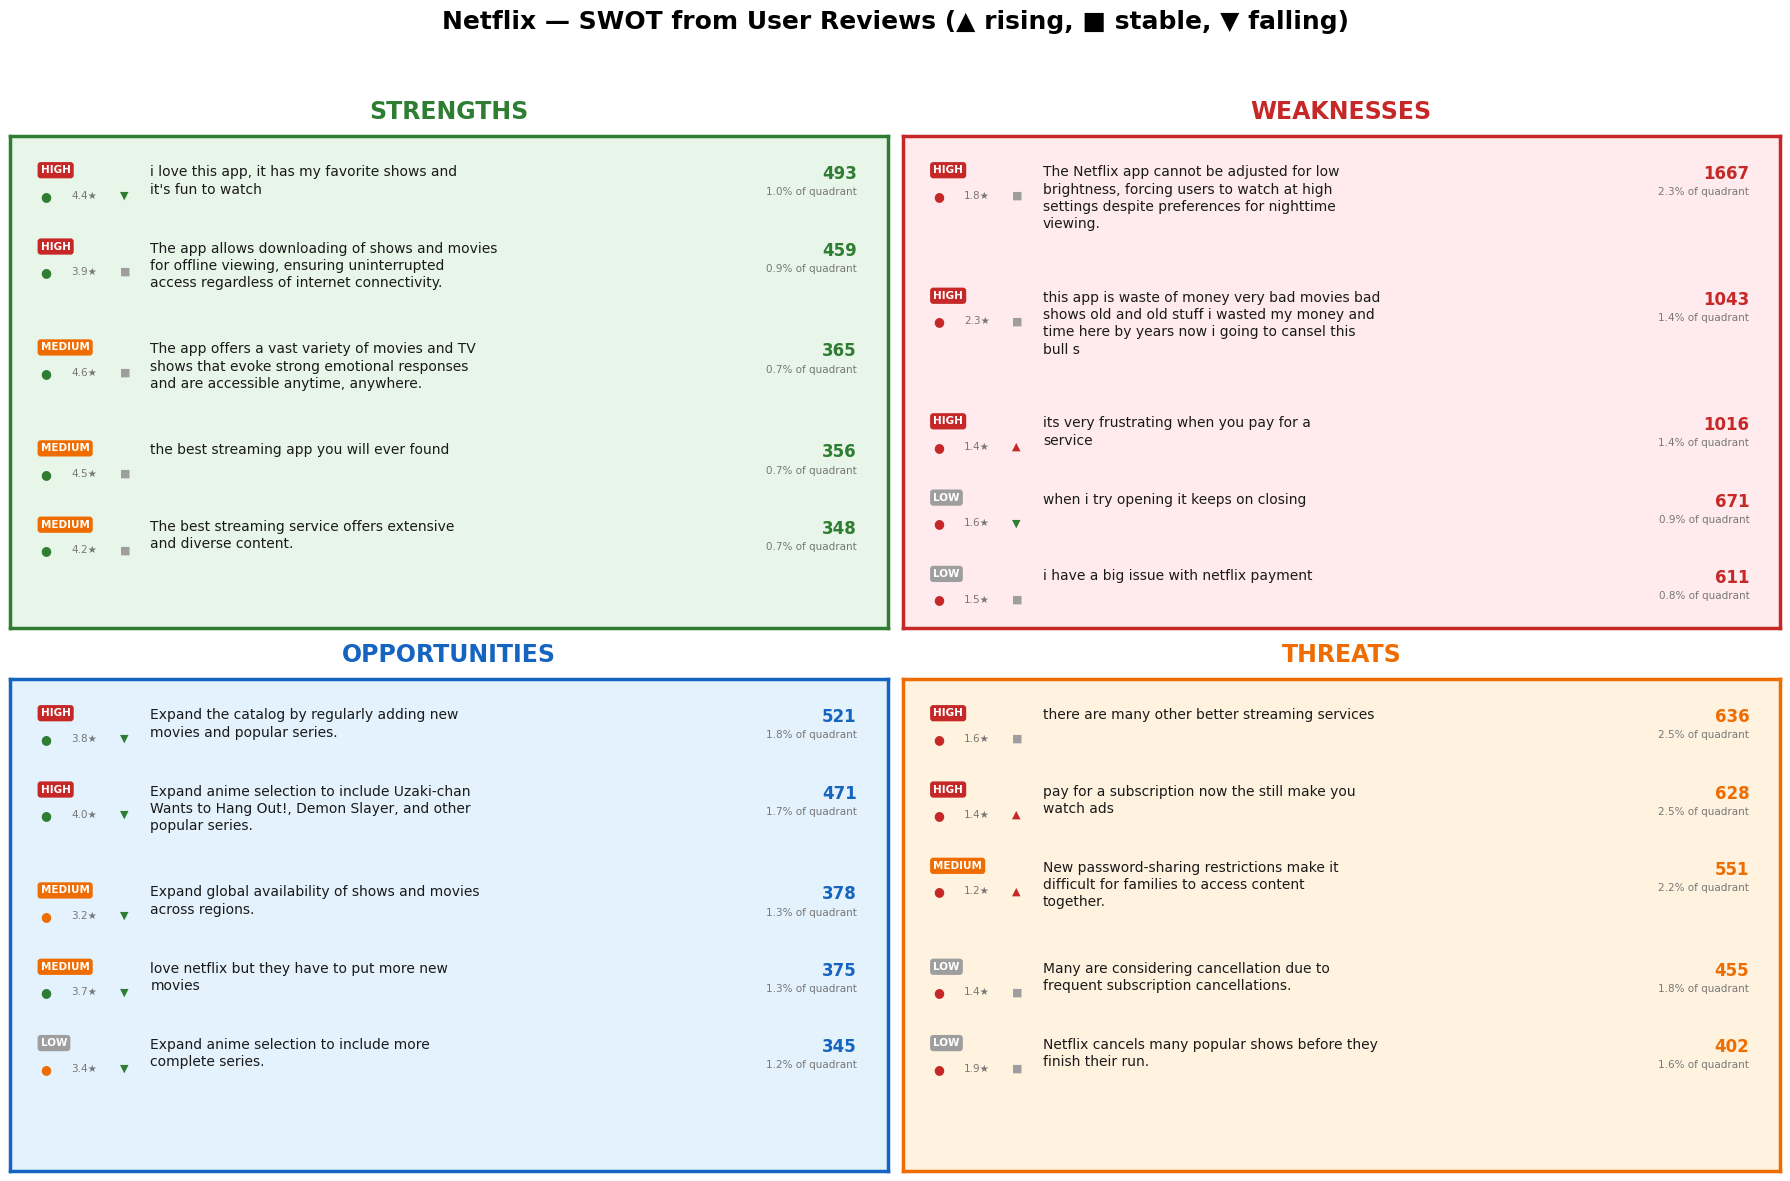

In [44]:
import matplotlib.pyplot as plt
import textwrap

QUAD = {
    "Strength":    ("STRENGTHS",     "#E8F5E9", "#2E7D32", (0, 0)),
    "Weakness":    ("WEAKNESSES",    "#FFEBEE", "#C62828", (0, 1)),
    "Opportunity": ("OPPORTUNITIES", "#E3F2FD", "#1565C0", (1, 0)),
    "Threat":      ("THREATS",       "#FFF3E0", "#EF6C00", (1, 1)),
}
PRIO_COLOR = {"HIGH": "#C62828", "MEDIUM": "#EF6C00", "LOW": "#9E9E9E"}
TREND_MARK = {"RISING": ("\u25b2", "#C62828"), "STABLE": ("\u25a0", "#9E9E9E"),
              "FALLING": ("\u25bc", "#2E7D32")}


def _wrap(t, w=46):
    return "\n".join(textwrap.wrap(str(t), width=w))


def draw_cell(ax, category):
    title, bg, border, _ = QUAD[category]
    sub = (final_swot[final_swot["swot"] == category]
           .sort_values("mention_count", ascending=False).head(5))
    ax.set_facecolor(bg); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    for sp in ax.spines.values():
        sp.set_linewidth(2.5); sp.set_edgecolor(border)
    ax.set_title(title, fontsize=17, fontweight="bold", color=border, pad=12)

    y, line_h, gap = 0.94, 0.05, 0.055
    for _, r in sub.iterrows():
        ax.text(0.035, y, r["priority"], transform=ax.transAxes, fontsize=7.5,
                fontweight="bold", va="top", ha="left", color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc=PRIO_COLOR[r["priority"]], ec="none"))
        ax.text(0.965, y, f'{int(r["mention_count"])}', transform=ax.transAxes,
                fontsize=12, fontweight="bold", va="top", ha="right", color=border)
        ax.text(0.965, y - 0.045, f'{r["share"]:.1f}% of quadrant', transform=ax.transAxes,
                fontsize=7.5, va="top", ha="right", color="#777777")
        wrapped = _wrap(r["business_insight"]); nlines = wrapped.count("\n") + 1
        ax.text(0.16, y, wrapped, transform=ax.transAxes, fontsize=10,
                va="top", ha="left", color="#1a1a1a", linespacing=1.3)
        sent = ("#2E7D32" if r["avg_rating"] >= 3.5
                else "#EF6C00" if r["avg_rating"] >= 2.5 else "#C62828")
        ax.text(0.035, y - 0.05, "\u25cf", transform=ax.transAxes, fontsize=9,
                va="top", ha="left", color=sent)
        ax.text(0.07, y - 0.052, f'{r["avg_rating"]:.1f}\u2605', transform=ax.transAxes,
                fontsize=7.5, va="top", ha="left", color="#777777")
        mark, mcol = TREND_MARK[r["trend"]]
        ax.text(0.125, y - 0.052, mark, transform=ax.transAxes,
                fontsize=8, va="top", ha="left", color=mcol)
        y -= max(nlines, 2) * line_h + gap


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Netflix — SWOT from User Reviews "
             "(\u25b2 rising, \u25a0 stable, \u25bc falling)",
             fontsize=18, fontweight="bold", y=0.98)
for category in QUAD:
    rr, cc = QUAD[category][3]
    draw_cell(axes[rr, cc], category)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/kaggle/working/swot_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
final_swot.to_csv("/kaggle/working/final_swot_matrix.csv", index=False)
print("Saved: final_swot_matrix.csv and swot_matrix.png")

Saved: final_swot_matrix.csv and swot_matrix.png


## 17. Summary

Reviews are cleaned, deduplicated order-independently, and segmented into
opinions; Qwen2.5-7B labels a fingerprinted silver corpus; a RoBERTa-large
student is distilled from it and evaluated on a review-grouped human gold set
with baselines, significance tests, and bootstrap intervals — under both the
argmax rule and the production rule. The full corpus is labelled with explicit
coverage reporting, BERTopic extracts themes per quadrant with measured c_v
coherence, and a grounding-gated LLM turns the surviving topics into a
prioritized SWOT matrix with quadrant-relative priorities and trend flags.

## 18. Try it on new reviews

In [46]:
# Classifier back on GPU for the demo and the explainability section.
if torch.cuda.is_available():
    classifier_model.to("cuda")
gc.collect(); torch.cuda.empty_cache()


def classify_sentence(sentence):
    segments = split_review_into_segments(sentence) or [sentence]
    p = predict_proba(segments)
    all_labels = set()
    for row in p:
        labels = [SWOT_LABELS[i] for i in range(4) if row[i] >= thr_vec[i]]
        if not labels:
            # Demo-only fallback to the top class; corpus labelling keeps
            # such segments as Unclassified instead.
            labels = [SWOT_LABELS[int(np.argmax(row))] + " (low confidence)"]
        all_labels.update(labels)
    return sorted(all_labels), segments


demo = [
    "great app, lots of movies",
    "the app crashes every time i open it",
    "please add greek subtitles",
    "too expensive, i am cancelling and switching to disney",
    "good interface but it keeps freezing",
    "love it but i wish it had more anime",
    "amazing library, great quality, but the price is too high",
]

for sentence in demo:
    labels, segments = classify_sentence(sentence)
    print(f">>> {sentence}")
    print(f"    SWOT: {', '.join(labels)}")
    for seg in segments:
        print(f'      - segment: "{seg}"')
    print()

>>> great app, lots of movies
    SWOT: Strength
      - segment: "great app, lots of movies"

>>> the app crashes every time i open it
    SWOT: Weakness
      - segment: "the app crashes every time i open it"

>>> please add greek subtitles
    SWOT: Opportunity
      - segment: "please add greek subtitles"

>>> too expensive, i am cancelling and switching to disney
    SWOT: Threat
      - segment: "too expensive, i am cancelling and switching to disney"

>>> good interface but it keeps freezing
    SWOT: Weakness
      - segment: "but it keeps freezing"

>>> love it but i wish it had more anime
    SWOT: Opportunity
      - segment: "but i wish it had more anime"

>>> amazing library, great quality, but the price is too high
    SWOT: Strength, Threat
      - segment: "amazing library, great quality"
      - segment: "the price is too high"



## 19. Charts and findings

All corpus-level charts use the classified segments only; the Unclassified
share is reported explicitly as coverage.

### 19.1 How many of each SWOT group

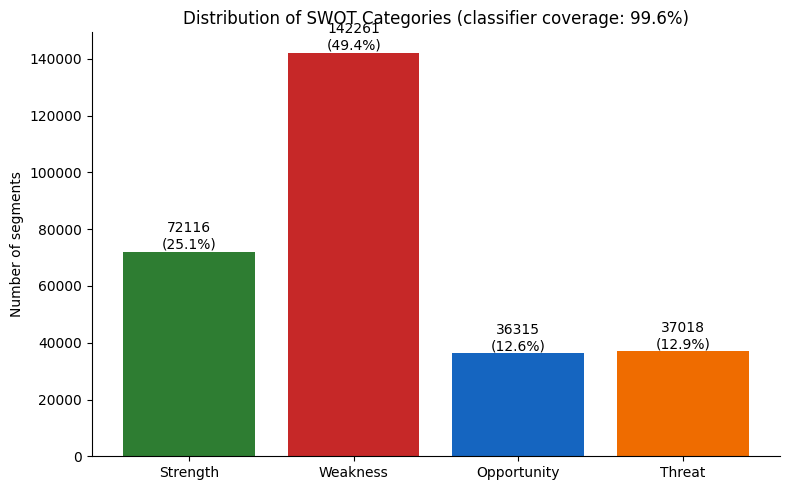

In [47]:
import matplotlib.pyplot as plt

COLORS = {"Strength": "#2E7D32", "Weakness": "#C62828",
          "Opportunity": "#1565C0", "Threat": "#EF6C00"}

counts = CLASSIFIED["swot_category"].value_counts().reindex(SWOT_LABELS).fillna(0)
pct = 100 * counts / counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(SWOT_LABELS, counts.values, color=[COLORS[l] for l in SWOT_LABELS])
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{int(b.get_height())}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of segments")
cov = (df_swot["swot_category"] != UNCLASSIFIED).mean()
ax.set_title(f"Distribution of SWOT Categories (classifier coverage: {cov:.1%})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_swot_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 19.2 SWOT groups by star rating

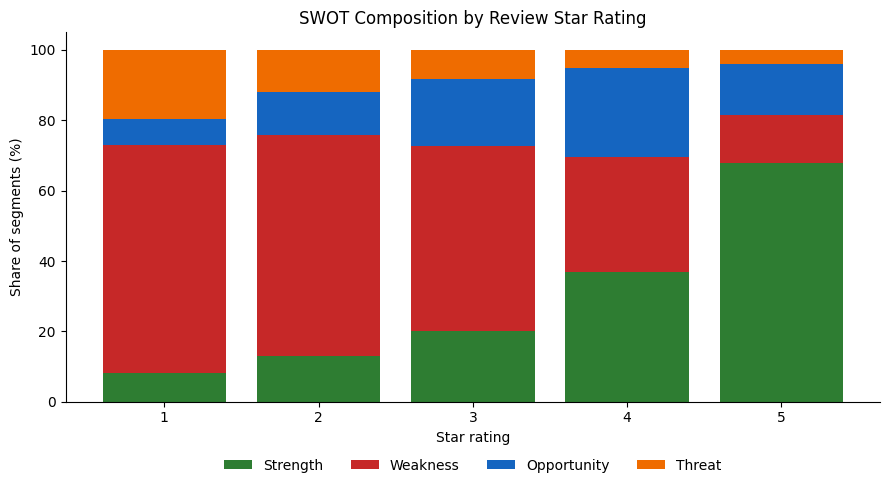

In [48]:
ct = pd.crosstab(CLASSIFIED["rating"], CLASSIFIED["swot_category"]).reindex(
    columns=SWOT_LABELS).fillna(0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(ct_pct))
for lab in SWOT_LABELS:
    ax.bar(ct_pct.index.astype(int).astype(str), ct_pct[lab], bottom=bottom,
           label=lab, color=COLORS[lab])
    bottom += ct_pct[lab].values
ax.set_xlabel("Star rating")
ax.set_ylabel("Share of segments (%)")
ax.set_title("SWOT Composition by Review Star Rating")
ax.legend(ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.12), loc="upper center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_swot_by_rating.png", dpi=150, bbox_inches="tight")
plt.show()

### 19.3 SWOT groups over time

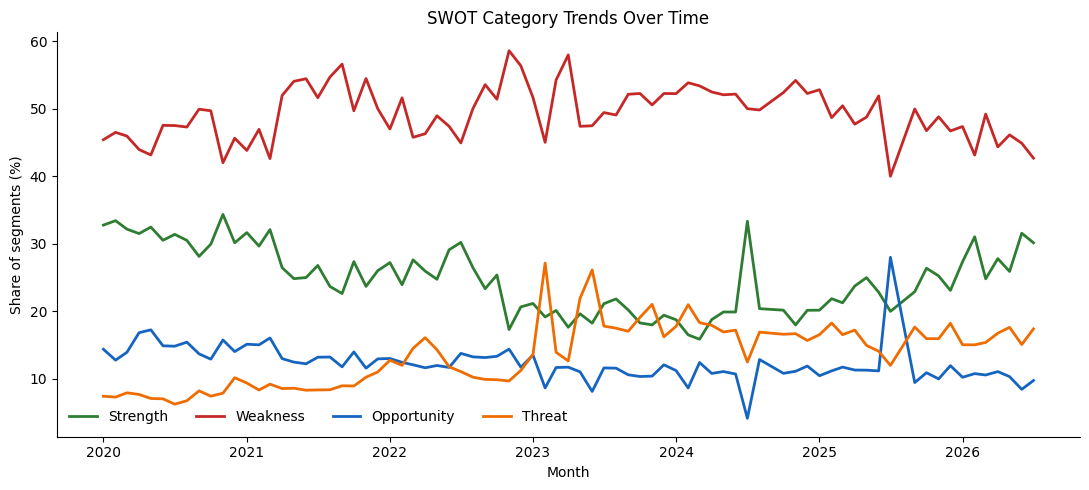

In [49]:
tmp = CLASSIFIED.copy()
tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
tmp = tmp.dropna(subset=["date"])
tmp["month"] = tmp["date"].dt.to_period("M").dt.to_timestamp()
monthly = pd.crosstab(tmp["month"], tmp["swot_category"]).reindex(columns=SWOT_LABELS).fillna(0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
monthly_pct = monthly_pct[monthly.sum(axis=1) >= 20]

fig, ax = plt.subplots(figsize=(11, 5))
for lab in SWOT_LABELS:
    ax.plot(monthly_pct.index, monthly_pct[lab], label=lab, color=COLORS[lab], linewidth=2)
ax.set_xlabel("Month")
ax.set_ylabel("Share of segments (%)")
ax.set_title("SWOT Category Trends Over Time")
ax.legend(ncol=4, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_swot_trend.png", dpi=150, bbox_inches="tight")
plt.show()

### 19.3b The COVID-19 window

Segments in Covid period: 92,118 (32.0% of classified)
Average rating  -  Covid: 2.89 |  Other: 2.24


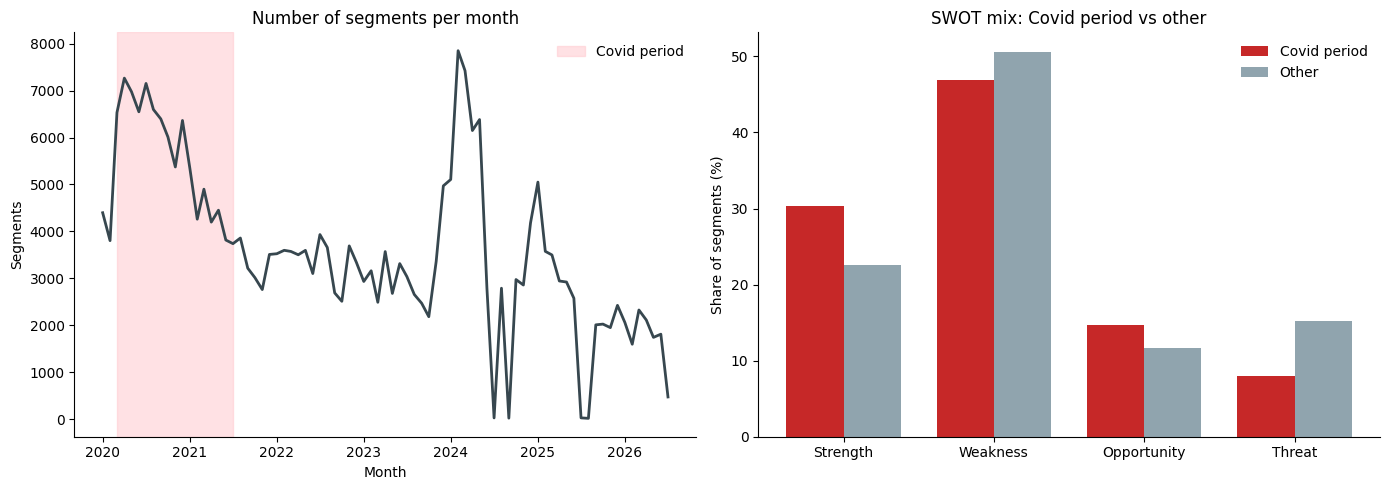


SWOT mix (%):
swot_category  Strength  Weakness  Opportunity  Threat
period                                                
Covid period       30.4      46.9         14.7     8.0
Other              22.6      50.6         11.6    15.2


In [50]:
COVID_START, COVID_END = "2020-03-01", "2021-06-30"

cov = CLASSIFIED.copy()
cov["date"] = pd.to_datetime(cov["date"], errors="coerce")
cov = cov.dropna(subset=["date"])
cov["period"] = np.where((cov["date"] >= COVID_START) & (cov["date"] <= COVID_END),
                         "Covid period", "Other")

print(f"Segments in Covid period: {(cov['period'] == 'Covid period').sum():,} "
      f"({(cov['period'] == 'Covid period').mean() * 100:.1f}% of classified)")
print(f"Average rating  -  Covid: {cov.loc[cov['period'] == 'Covid period', 'rating'].mean():.2f} "
      f"|  Other: {cov.loc[cov['period'] == 'Other', 'rating'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cov["month"] = cov["date"].dt.to_period("M").dt.to_timestamp()
vol = cov.groupby("month").size()
axes[0].plot(vol.index, vol.values, color="#37474F", linewidth=2)
axes[0].axvspan(pd.to_datetime(COVID_START), pd.to_datetime(COVID_END),
                color="#FFCDD2", alpha=0.6, label="Covid period")
axes[0].set_title("Number of segments per month")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Segments")
axes[0].legend(frameon=False); axes[0].spines[["top", "right"]].set_visible(False)

comp = pd.crosstab(cov["period"], cov["swot_category"]).reindex(columns=SWOT_LABELS).fillna(0)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100
x = np.arange(len(SWOT_LABELS)); w = 0.38
axes[1].bar(x - w / 2, comp_pct.loc["Covid period"], w, label="Covid period", color="#C62828")
axes[1].bar(x + w / 2, comp_pct.loc["Other"], w, label="Other", color="#90A4AE")
axes[1].set_xticks(x); axes[1].set_xticklabels(SWOT_LABELS)
axes[1].set_ylabel("Share of segments (%)")
axes[1].set_title("SWOT mix: Covid period vs other")
axes[1].legend(frameon=False); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_covid_period.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSWOT mix (%):")
print(comp_pct.round(1))

### 19.4 Top topics per group

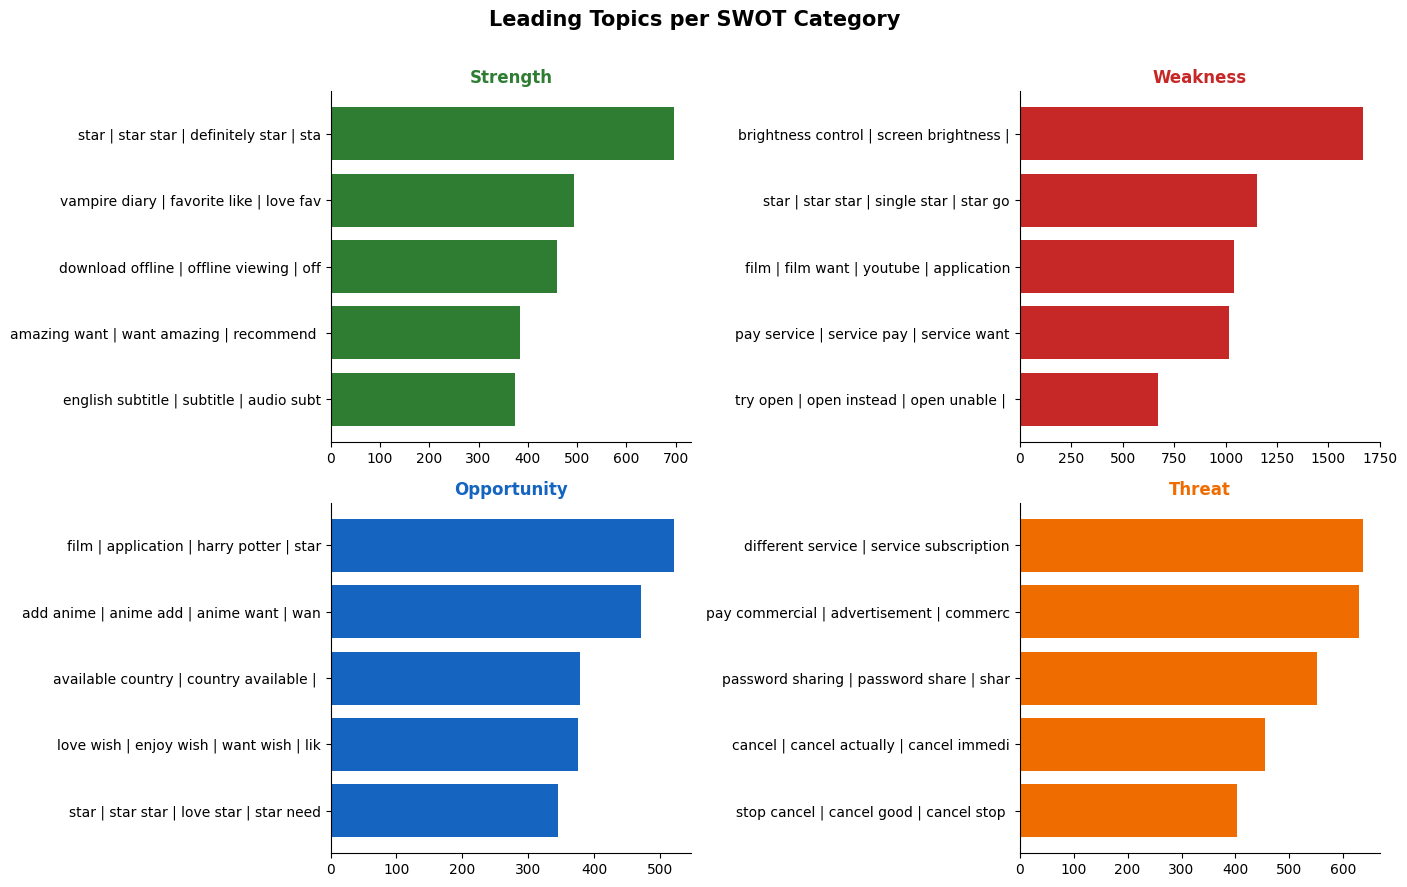

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, cat in zip(axes.ravel(), SWOT_LABELS):
    table = topic_tables.get(cat, pd.DataFrame())
    if len(table) == 0:
        ax.text(0.5, 0.5, f"{cat}\n(no topics)", ha="center", va="center")
        ax.axis("off"); continue
    top = table.sort_values("mention_count", ascending=False).head(5)
    phrases = [p[:40] for p in top["topic_phrase"]][::-1]
    vals = list(top["mention_count"])[::-1]
    ax.barh(phrases, vals, color=COLORS[cat])
    ax.set_title(cat, color=COLORS[cat], fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Leading Topics per SWOT Category", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/kaggle/working/fig_top_topics.png", dpi=150, bbox_inches="tight")
plt.show()

### 19.5 Model performance

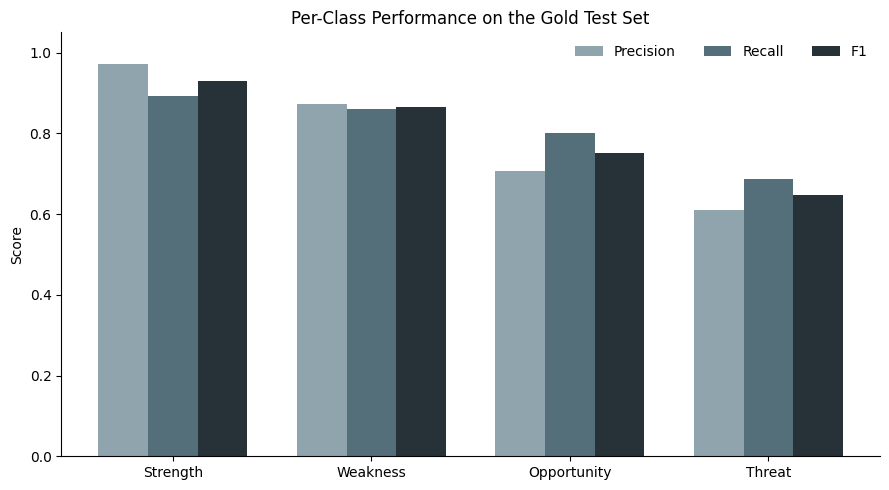

In [52]:
yt_perf = np.array([[1 if t == l else 0 for l in SWOT_LABELS] for t in true_label])
yp_perf = np.array([[1 if p == l else 0 for l in SWOT_LABELS] for p in pred_label])
prec_p, rec_p, f1_p, _ = precision_recall_fscore_support(
    yt_perf, yp_perf, labels=list(range(len(SWOT_LABELS))), zero_division=0)

x = np.arange(len(SWOT_LABELS)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w, prec_p, w, label="Precision", color="#90A4AE")
ax.bar(x, rec_p, w, label="Recall", color="#546E7A")
ax.bar(x + w, f1_p, w, label="F1", color="#263238")
ax.set_xticks(x); ax.set_xticklabels(SWOT_LABELS)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Per-Class Performance on the Gold Test Set")
ax.legend(frameon=False, ncol=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_per_class_perf.png", dpi=150, bbox_inches="tight")
plt.show()

## 20. Which words drive the predictions

Word-level occlusion: remove one word at a time and measure the drop in the
predicted-class probability. Used for the interactive visualizations; the
formal faithfulness evaluation in Section 20.5 scores the Integrated Gradients
attributions, not the occlusion scores themselves.

In [53]:
STOP = {"i", "it", "is", "a", "the", "to", "my", "on", "of", "and", "for", "this",
        "that", "in", "so", "im", "its", "was", "be", "you", "me", "with", "at",
        "as", "are", "have", "but", "or"}


def explain_occlusion(text):
    words = str(text).split()
    if len(words) < 2:
        return None
    base = predict_proba([text])[0]
    cls = int(np.argmax(base)); base_p = float(base[cls])
    variants = [" ".join(words[:i] + words[i + 1:]) for i in range(len(words))]
    p_var = predict_proba(variants)
    contribs = [(words[i], base_p - float(p_var[i][cls])) for i in range(len(words))]
    return {"label": SWOT_LABELS[cls], "confidence": base_p, "contributions": contribs}


def _meaningful(contribs):
    out = []
    for w, v in contribs:
        wl = w.lower().strip(".,!?\"'")
        if wl not in STOP and len(wl) > 2 and abs(v) > 0.01:
            out.append((w, v))
    return out


def plot_attribution(text, ax=None):
    res = explain_occlusion(text)
    if res is None:
        return
    kept = _meaningful(res["contributions"]) or res["contributions"]
    words = [w for w, _ in kept]
    vals = np.array([v for _, v in kept])
    cols = ["#C62828" if v < 0 else COLORS.get(res["label"], "#2E7D32") for v in vals]
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 2.6))
    ax.barh(range(len(words)), vals, color=cols)
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_title(f'Predicted: {res["label"]} ({res["confidence"]:.2f}) — "{text[:45]}…"',
                 fontsize=10)
    ax.set_xlabel("Influence on prediction")
    ax.spines[["top", "right"]].set_visible(False)

### 20.1 A few examples

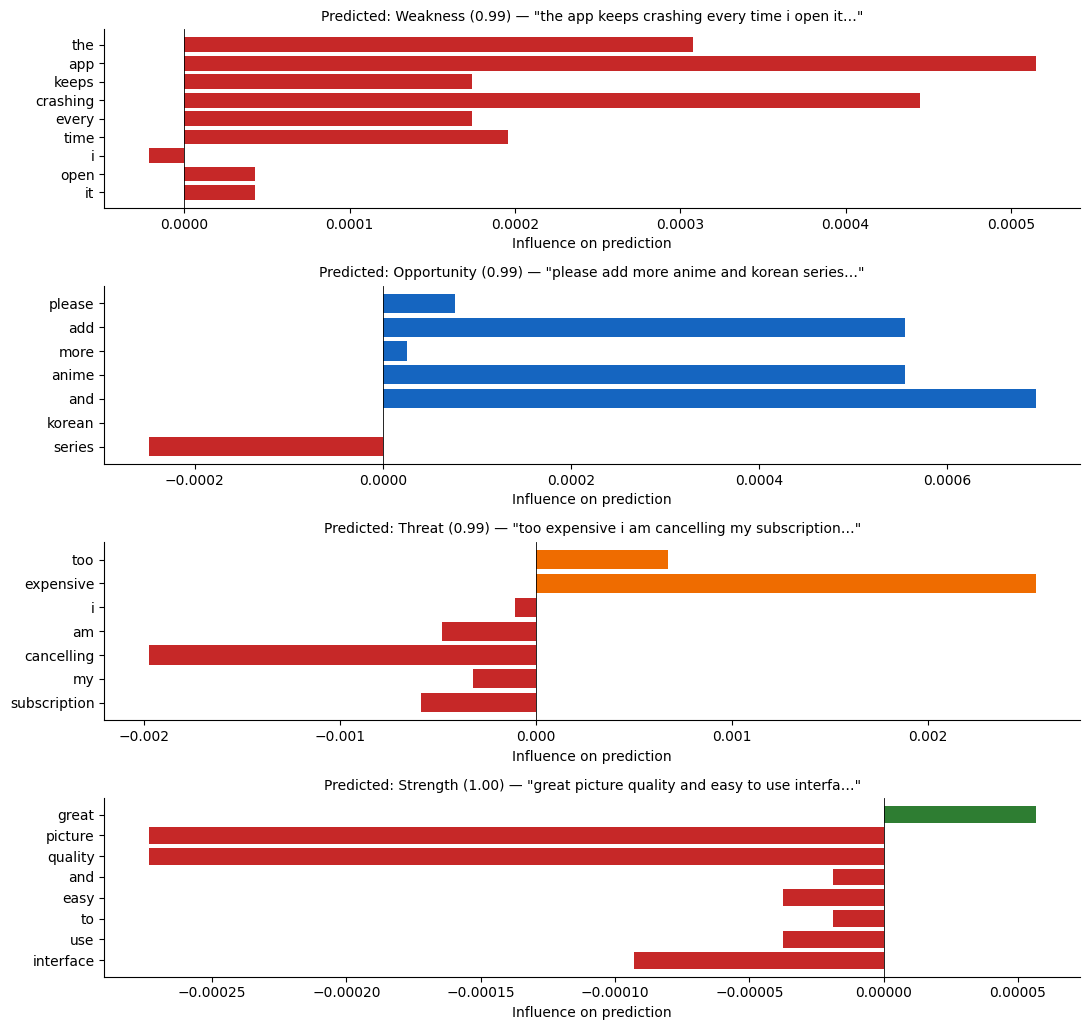

In [54]:
xai_examples = [
    "the app keeps crashing every time i open it",
    "please add more anime and korean series",
    "too expensive i am cancelling my subscription",
    "great picture quality and easy to use interface",
]
fig, axes = plt.subplots(len(xai_examples), 1, figsize=(11, 2.6 * len(xai_examples)))
for ax, ex in zip(axes, xai_examples):
    plot_attribution(ex, ax=ax)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_token_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 20.2 Distinctive vocabulary per group

v2: the word clouds now weight terms by **per-category TF-IDF** (each category
as one document against the other three), so shared vocabulary is suppressed
and each cloud shows what makes its category distinctive; a single hue per
category replaces the earlier decorative multicolour map.

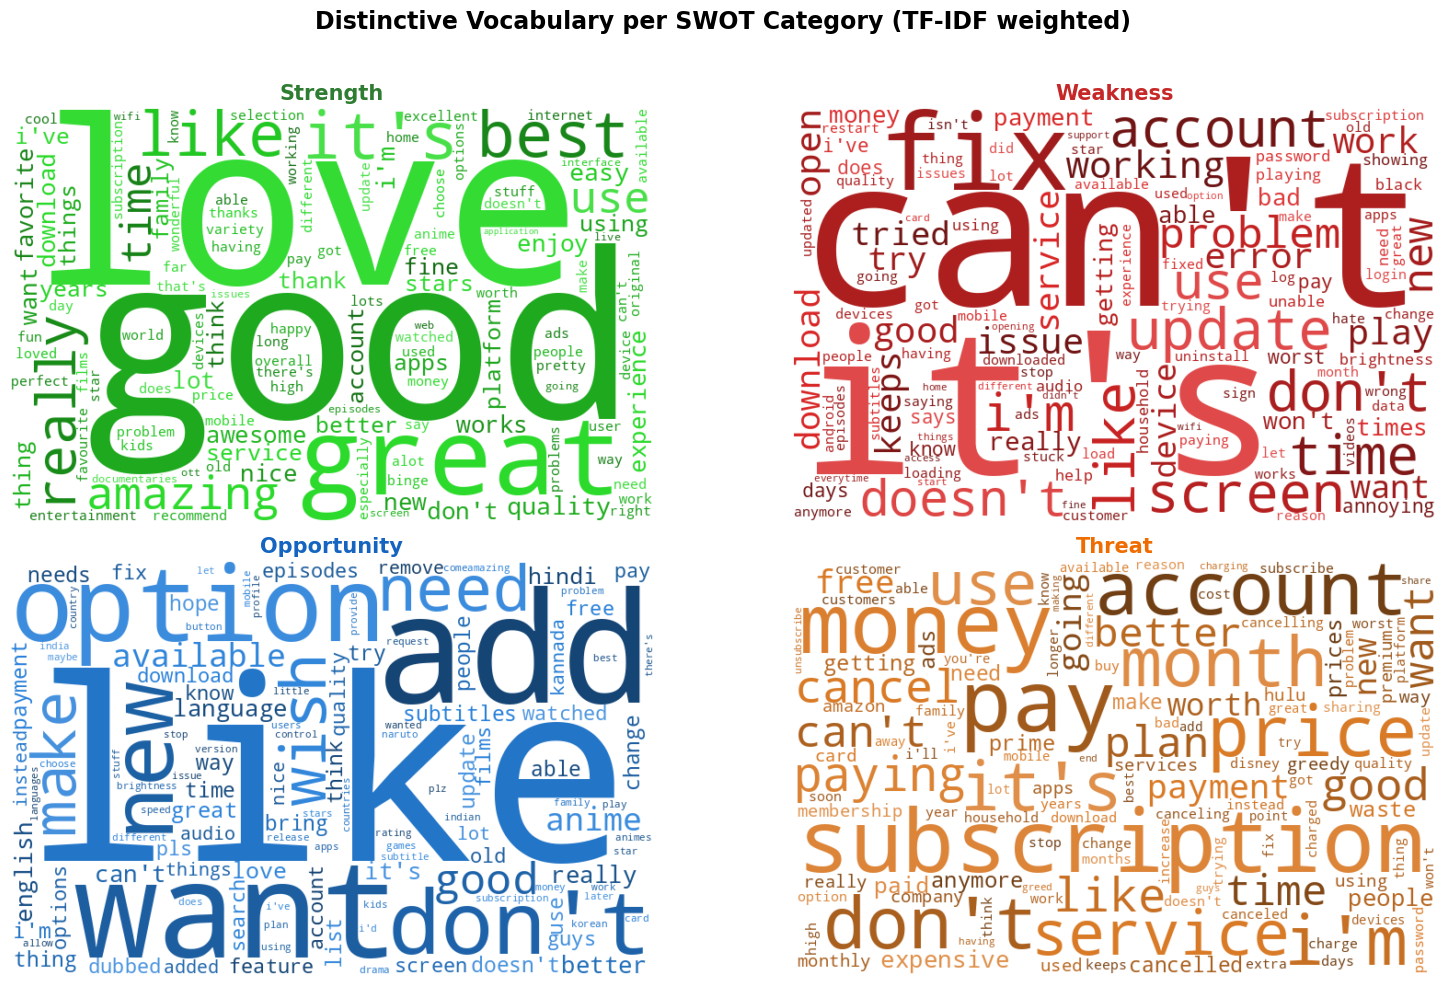

In [55]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import random

WC_STOP = STOP_LIST + ["im", "dont", "get", "just", "even", "will", "cant"]
MAX_TEXTS = 20000        # cap per category to keep the vectorizer light

mega_docs = []
for cat in SWOT_LABELS:
    texts_c = CLASSIFIED.loc[CLASSIFIED["swot_category"] == cat, "text_clean"].astype(str)
    if len(texts_c) > MAX_TEXTS:
        texts_c = texts_c.sample(MAX_TEXTS, random_state=SEED)
    mega_docs.append(" ".join(texts_c))

wc_vec = TfidfVectorizer(stop_words=WC_STOP, max_features=4000,
                         token_pattern=r"[a-zA-Z']{3,}")
X = wc_vec.fit_transform(mega_docs)
vocab = np.array(wc_vec.get_feature_names_out())

BASE_HUE = {"Strength": 120, "Weakness": 0, "Opportunity": 210, "Threat": 28}


def make_color_func(cat):
    def cf(word, font_size, position, orientation, random_state=None, **kw):
        light = 25 + int(random.Random(hash(word)).random() * 35)
        return f"hsl({BASE_HUE[cat]}, 70%, {light}%)"
    return cf


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, (ax, cat) in enumerate(zip(axes.ravel(), SWOT_LABELS)):
    weights = dict(zip(vocab, X[i].toarray().ravel()))
    weights = {w: v for w, v in weights.items() if v > 0}
    ax.axis("off")
    ax.set_title(cat, color=COLORS[cat], fontweight="bold", fontsize=15)
    if weights:
        wc = WordCloud(width=700, height=450, background_color="white",
                       max_words=120, prefer_horizontal=0.9, relative_scaling=0.4,
                       color_func=make_color_func(cat)).generate_from_frequencies(weights)
        ax.imshow(wc, interpolation="bilinear")
fig.suptitle("Distinctive Vocabulary per SWOT Category (TF-IDF weighted)",
             fontsize=17, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("/kaggle/working/fig_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
from IPython.display import HTML, display


def explain_sentence_html(text):
    res = explain_occlusion(text)
    if res is None:
        return ""
    vals = np.array([v for _, v in res["contributions"]])
    m = float(np.abs(vals).max()) or 1.0
    spans = []
    for w, v in res["contributions"]:
        inten = min(abs(v) / m, 1.0)
        rgb = "46,125,50" if v >= 0 else "198,40,40"
        spans.append(f'<span style="background:rgba({rgb},{inten:.2f});'
                     f'padding:2px 4px;border-radius:3px;margin:1px;">{w}</span>')
    return (f'<div style="font-family:sans-serif;font-size:15px;margin:10px 0;line-height:2.0;">'
            f'<b style="color:{COLORS[res["label"]]};">&rarr; {res["label"]}</b> '
            f'<span style="color:#999;">(confidence {res["confidence"]:.2f})</span><br>'
            + " ".join(spans) + "</div>")


html_examples = [
    "the app keeps crashing every time i open it",
    "great picture quality and very easy to use",
    "please add more korean and anime series",
    "way too expensive now, i am cancelling my subscription",
    "the new update removed my favourite shows",
]
display(HTML("<h4>How the model reads each sentence "
             "(green = pushed toward the label, red = against)</h4>"
             + "".join(explain_sentence_html(t) for t in html_examples)))

In [57]:
errors_view = pd.DataFrame({"text": human_test["text_clean"],
                            "true": true_label, "pred": pred_label})
errors_view = errors_view[errors_view["true"] != errors_view["pred"]].head(6)
display(HTML("<h4>Why the model made these mistakes</h4>" +
    "".join(f'<div style="color:#888;font-size:13px;">true: <b>{r.true}</b></div>'
            + explain_sentence_html(r.text) for r in errors_view.itertuples())))

### 20.3 SHAP (global-style view on examples)

In [58]:
!pip install shap -q

import shap


def shap_predict(texts):
    return predict_proba(list(texts))


masker = shap.maskers.Text(r"\W+")          # word-level masking (not subwords)
explainer = shap.Explainer(shap_predict, masker, output_names=SWOT_LABELS)

shap_examples = [
    "the app keeps crashing every time i open it",
    "great picture quality and very easy to use",
    "please add more korean and anime series",
    "way too expensive now i am cancelling my subscription",
    "the new update removed my favourite shows",
]
shap_values = explainer(shap_examples)

for i, txt in enumerate(shap_examples):
    cls = int(np.argmax(predict_proba([txt])[0]))
    print(f"\n-> Predicted: {SWOT_LABELS[cls]}")
    shap.plots.text(shap_values[i, :, cls])


-> Predicted: Weakness



-> Predicted: Strength



-> Predicted: Opportunity



-> Predicted: Threat



-> Predicted: Weakness


### 20.4 LIME on one real review per class

Auto-selected real reviews:
  [Strength] great app , its worldwide used not yet an obsession for me
  [Weakness] your tv app is ridiculous, its been months and its constantly glitches
  [Opportunity] it's good but more ppl should be able to watch shows on different devices
  [Threat] tired of cost changes now limiting downloads per month i'm done


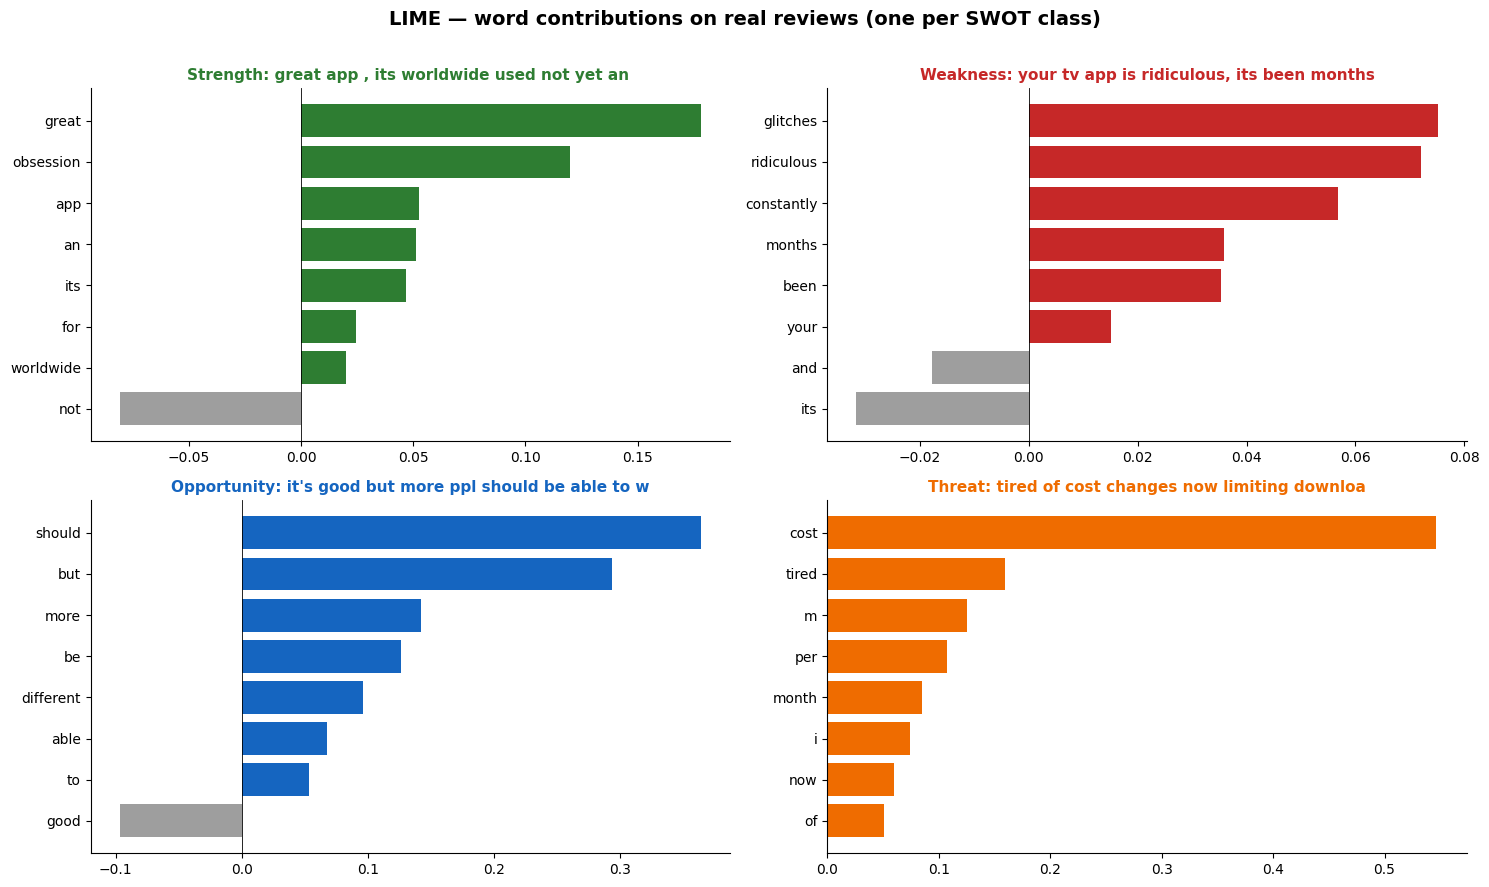

In [59]:
!pip install lime -q
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(class_names=SWOT_LABELS)


def lime_predict(texts):
    return predict_proba(list(texts))


def pick_real_example(cat, min_w=5, max_w=14):
    sub = CLASSIFIED[CLASSIFIED["swot_category"] == cat].copy()
    sub["_nw"] = sub["text_clean"].astype(str).str.split().str.len()
    pool = sub[(sub["_nw"] >= min_w) & (sub["_nw"] <= max_w)]
    if len(pool) == 0:
        pool = sub
    return pool.sort_values("swot_confidence", ascending=False).iloc[0]["text_clean"]


real_examples = [pick_real_example(cat) for cat in SWOT_LABELS]
print("Auto-selected real reviews:")
for cat, ex in zip(SWOT_LABELS, real_examples):
    print(f"  [{cat}] {ex}")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, txt in zip(axes.ravel(), real_examples):
    cls = int(np.argmax(predict_proba([txt])[0]))
    exp = lime_explainer.explain_instance(txt, lime_predict, num_features=8,
                                          labels=[cls], num_samples=800)
    items = sorted(exp.as_list(label=cls), key=lambda x: x[1])
    words = [w for w, _ in items]; vals = [v for _, v in items]
    cols = [COLORS[SWOT_LABELS[cls]] if v >= 0 else "#9E9E9E" for v in vals]
    ax.barh(range(len(words)), vals, color=cols)
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words, fontsize=10)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_title(f"{SWOT_LABELS[cls]}: {txt[:42]}",
                 color=COLORS[SWOT_LABELS[cls]], fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("LIME — word contributions on real reviews (one per SWOT class)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/kaggle/working/fig_lime.png", dpi=150, bbox_inches="tight")
plt.show()

### 20.5 Integrated Gradients and faithfulness

v2: IG attributions are aggregated from subword tokens to whitespace words via
character offsets, so the same word units feed the visualization *and* the
deletion/insertion faithfulness curves. Faithfulness now scores the **IG
ordering** (the featured explanation method) against an occlusion ordering and
a random-order baseline — evaluating occlusion with occlusion-based curves, as
before, was circular.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.9 MB/s eta 0:00:00:00:01


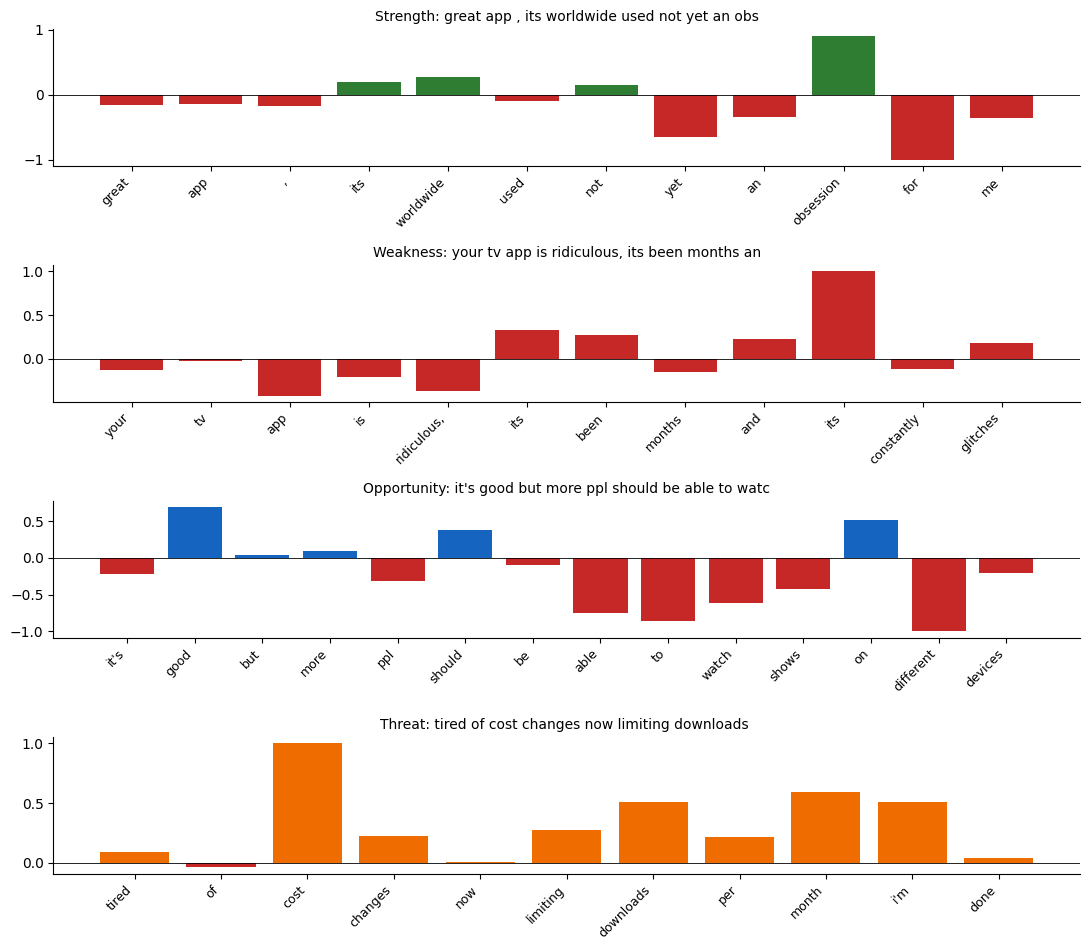

In [60]:
!pip install captum -q
from captum.attr import LayerIntegratedGradients

clf = classifier_model
tok = classifier_tokenizer
device = clf.device


def _forward(input_ids, attention_mask):
    return clf(input_ids=input_ids, attention_mask=attention_mask).logits


lig = LayerIntegratedGradients(_forward, clf.get_input_embeddings())


def ig_word_importance(text):
    """IG token attributions mapped to whitespace words via char offsets."""
    text = str(text)
    words = text.split()
    if len(words) < 2:
        return None, None, None
    spans, pos = [], 0
    for w in words:
        start = text.find(w, pos)
        spans.append((start, start + len(w)))
        pos = start + len(w)
    enc = tok(text, return_tensors="pt", truncation=True, max_length=64,
              return_offsets_mapping=True)
    offsets = enc.pop("offset_mapping")[0].tolist()
    enc = {k: v.to(device) for k, v in enc.items()}
    ids, mask = enc["input_ids"], enc["attention_mask"]
    with torch.no_grad():
        cls = int(clf(input_ids=ids, attention_mask=mask).logits.argmax())
    ref = torch.full_like(ids, tok.pad_token_id)
    ref[0, 0] = ids[0, 0]; ref[0, -1] = ids[0, -1]
    attr = lig.attribute(inputs=ids, baselines=ref, additional_forward_args=(mask,),
                         target=cls, n_steps=40)
    tok_scores = attr.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    imp = np.zeros(len(words))
    for (s, e), sc in zip(offsets, tok_scores):
        if e == 0:                      # special tokens
            continue
        for wi, (ws, we) in enumerate(spans):
            if ws <= s < we:
                imp[wi] += sc
                break
    return words, cls, imp


fig, axes = plt.subplots(len(real_examples), 1, figsize=(11, 2.4 * len(real_examples)))
for ax, txt in zip(axes, real_examples):
    words, cls, imp = ig_word_importance(txt)
    if imp is None:
        continue
    vals = imp / (np.abs(imp).max() + 1e-9)
    cols = ["#C62828" if v < 0 else COLORS[SWOT_LABELS[cls]] for v in vals]
    ax.bar(range(len(words)), vals, color=cols)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right", fontsize=9)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(f"{SWOT_LABELS[cls]}: {txt[:45]}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_integrated_gradients.png", dpi=150, bbox_inches="tight")
plt.show()

AOPC (higher = more faithful ordering):
  IG         deletion = 0.440 | insertion = 0.455
  Occlusion  deletion = 0.532 | insertion = 0.538
  Random     deletion = 0.347 | insertion = 0.357

IG gain over random: deletion +0.093 | insertion +0.097


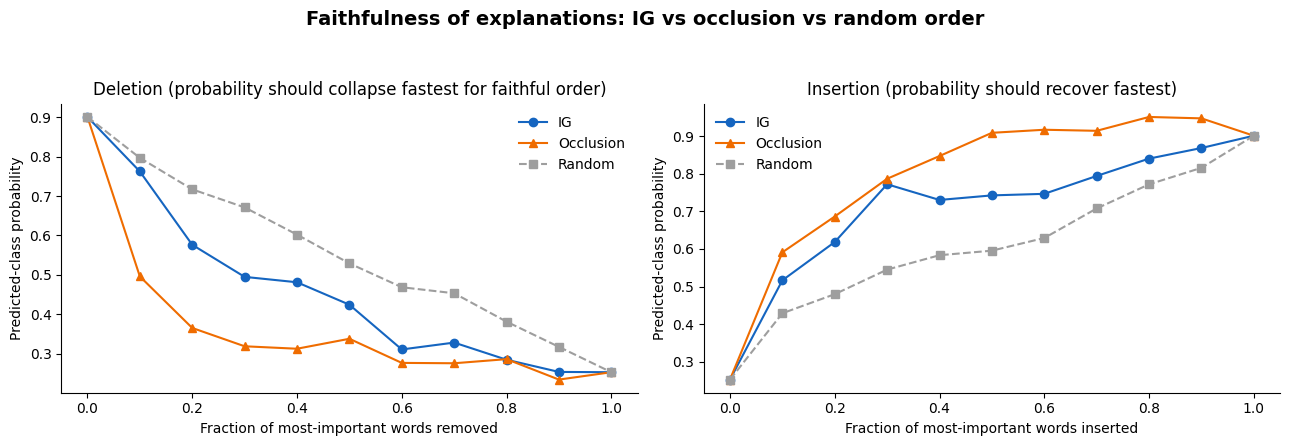

In [61]:
# Faithfulness: deletion/insertion curves under three word orderings —
# Integrated Gradients (featured method), occlusion, and random baseline.
STEPS = 10
FR = np.linspace(0, 1, STEPS + 1)
rng_f = np.random.RandomState(SEED)


def occlusion_word_importance(text):
    words = str(text).split()
    if len(words) < 2:
        return None, None, None
    base = predict_proba([text])[0]
    cls = int(np.argmax(base)); base_p = float(base[cls])
    variants = [" ".join(words[:i] + words[i + 1:]) for i in range(len(words))]
    p_var = predict_proba(variants)
    imp = np.array([base_p - float(p_var[i][cls]) for i in range(len(words))])
    return words, cls, imp


def curves_for_order(words, cls, order):
    n = len(words)
    del_txts = [" ".join([w for j, w in enumerate(words)
                          if j not in set(order[:int(round(f * n))])]) for f in FR]
    ins_txts = [" ".join([w for j, w in enumerate(words)
                          if j in set(order[:int(round(f * n))])]) for f in FR]
    dp = predict_proba([t if t.strip() else " " for t in del_txts])[:, cls]
    ip = predict_proba([t if t.strip() else " " for t in ins_txts])[:, cls]
    return dp, ip


# Sample of real reviews (moderate length) across categories.
faith_sample = CLASSIFIED.copy()
faith_sample["_nw"] = faith_sample["text_clean"].astype(str).str.split().str.len()
faith_sample = faith_sample[(faith_sample["_nw"] >= 5) & (faith_sample["_nw"] <= 20)]
faith_sample = faith_sample.groupby("swot_category").head(15)      # ~60 reviews

curves = {"IG": {"del": [], "ins": []},
          "Occlusion": {"del": [], "ins": []},
          "Random": {"del": [], "ins": []}}

for t in faith_sample["text_clean"]:
    words, cls, imp_ig = ig_word_importance(t)
    if imp_ig is None:
        continue
    _, _, imp_oc = occlusion_word_importance(t)
    orders = {"IG": np.argsort(-imp_ig),
              "Occlusion": np.argsort(-imp_oc),
              "Random": rng_f.permutation(len(words))}
    for name, order in orders.items():
        dp, ip = curves_for_order(words, cls, order)
        curves[name]["del"].append(dp)
        curves[name]["ins"].append(ip)

aopc = {}
for name, cs in curves.items():
    D = np.array(cs["del"]); I = np.array(cs["ins"])
    aopc[name] = {"del": float(np.mean(D[:, 0:1] - D)),
                  "ins": float(np.mean(I - I[:, 0:1])),
                  "D": D, "I": I}

print("AOPC (higher = more faithful ordering):")
for name in ["IG", "Occlusion", "Random"]:
    print(f"  {name:10} deletion = {aopc[name]['del']:.3f} | insertion = {aopc[name]['ins']:.3f}")
print(f"\nIG gain over random: deletion {aopc['IG']['del'] - aopc['Random']['del']:+.3f} "
      f"| insertion {aopc['IG']['ins'] - aopc['Random']['ins']:+.3f}")

STYLE = {"IG": ("#1565C0", "o", "-"), "Occlusion": ("#EF6C00", "^", "-"),
         "Random": ("#9E9E9E", "s", "--")}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in ["IG", "Occlusion", "Random"]:
    col, mk, ls = STYLE[name]
    axes[0].plot(FR, aopc[name]["D"].mean(0), marker=mk, color=col,
                 linestyle=ls, label=name)
    axes[1].plot(FR, aopc[name]["I"].mean(0), marker=mk, color=col,
                 linestyle=ls, label=name)
axes[0].set_title("Deletion (probability should collapse fastest for faithful order)")
axes[0].set_xlabel("Fraction of most-important words removed")
axes[0].set_ylabel("Predicted-class probability")
axes[1].set_title("Insertion (probability should recover fastest)")
axes[1].set_xlabel("Fraction of most-important words inserted")
axes[1].set_ylabel("Predicted-class probability")
for ax in axes:
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Faithfulness of explanations: IG vs occlusion vs random order",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/kaggle/working/fig_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()

## 21. Export dashboard data (`data.json`)

Final step of every run. Serialises the pipeline outputs into the exact JSON schema the **ReviewLens dashboard** fetches on load, and writes it to `/kaggle/working/data.json`. This file is what the monthly automation picks up and publishes next to the dashboard.


In [ ]:
# =====================================================================
# 21. Export dashboard data  ->  /kaggle/working/data.json
# The ReviewLens dashboard fetches a sibling `data.json` at mount time and
# merges it over its built-in sample data. This cell serialises the final
# pipeline objects into exactly the schema the dashboard expects.
# =====================================================================
import json, re
import numpy as np
import pandas as pd


def _py(o):
    """Coerce numpy/pandas scalars to plain Python so json.dump won't choke."""
    if isinstance(o, dict):          return {k: _py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_py(v) for v in o]
    if isinstance(o, np.integer):    return int(o)
    if isinstance(o, np.floating):   return float(o)
    if isinstance(o, np.bool_):      return bool(o)
    return o


def _title_from_phrase(phrase, k=2):
    terms = [t.strip() for t in str(phrase).split("|") if t.strip()]
    return " ".join(w.capitalize() for w in terms[:k]) if terms else "Topic"


# ---- quote text -> (rating, "Mon YYYY"), built once from the classified corpus
_cl = CLASSIFIED.copy()
_cl["date"] = pd.to_datetime(_cl["date"], errors="coerce")
_cl["text_clean"] = _cl["text_clean"].astype(str)
_quote_lookup = {}
for _t, _r, _d in zip(_cl["text_clean"], _cl["rating"], _cl["date"]):
    _t = _t.strip()
    if _t and _t not in _quote_lookup:
        _quote_lookup[_t] = (int(_r) if pd.notna(_r) else 3,
                             _d.strftime("%b %Y") if pd.notna(_d) else "")


def _quote_meta(text, fallback_rating):
    text = str(text).strip()
    hit = _quote_lookup.get(text)
    if hit:
        return [hit[0], text, hit[1]]
    return [int(round(fallback_rating)), text, ""]


# ---- topics: final_swot rows, quotes recovered from topic_tables ----
_topics, _counters = [], {c: 0 for c in SWOT_LABELS}
_prefix = {"Strength": "s", "Weakness": "w", "Opportunity": "o", "Threat": "t"}
for _, row in final_swot.iterrows():
    cat = row["swot"]
    tbl = topic_tables.get(cat, pd.DataFrame())
    match = tbl[tbl["topic_phrase"] == row["topic_phrase"]] if len(tbl) else tbl
    if len(match):
        raw_quotes = [match.iloc[0].get(f"quote_{i}", "") for i in range(1, 7)]
    else:
        raw_quotes = [row.get("quote_1", "")]
    avg_r = float(row["avg_rating"])
    quotes = [_quote_meta(q, avg_r) for q in raw_quotes if str(q).strip()]
    _counters[cat] += 1
    _topics.append({
        "id": f"{_prefix[cat]}{_counters[cat]}",
        "quad": cat,
        "name": _title_from_phrase(row["topic_phrase"]),
        "phrase": str(row["topic_phrase"]),
        "mentions": int(row["mention_count"]),
        "avgRating": round(avg_r, 1),
        "trend": str(row["trend"]),
        "prio": str(row["priority"]),
        "insight": str(row["business_insight"]),
        "quotes": quotes,
    })

# ---- meta ----
_meta = {
    "total_reviews":      int(df_swot["review_id"].nunique()),
    "total_opinions":     int(len(df_swot)),
    "avg_rating":         round(float(df_raw["rating"].mean()), 2),
    "positive_share_pct": round(float((df_raw["rating"] >= 4).mean()) * 100, 1),
    "coverage_pct":       round(float(globals().get("coverage",
                              (df_swot["swot_category"] != UNCLASSIFIED).mean())) * 100, 1),
    "macro_f1":           round(float(globals().get("macro_f1", 0.0)), 2),
}

# ---- history: last 6 completed monthly cumulative snapshots (for KPI sparklines)
_rr = df_raw.dropna(subset=["date"]).copy()
_rr["date"] = pd.to_datetime(_rr["date"], errors="coerce")
_rr = _rr.dropna(subset=["date"]).sort_values("date")
_rr["month"] = _rr["date"].dt.to_period("M")
_this_month = pd.Timestamp.today().to_period("M")
_months = [m for m in sorted(_rr["month"].unique()) if m < _this_month]
_history = []
for _m in (_months[-6:] if len(_months) >= 6 else _months):
    _upto = _rr[_rr["month"] <= _m]
    _history.append({
        "total_reviews":      int(len(_upto)),
        "avg_rating":         round(float(_upto["rating"].mean()), 2),
        "positive_share_pct": round(float((_upto["rating"] >= 4).mean()) * 100, 1),
    })

# ---- quadTotals ----
_quadTotals = {c: int(QUAD_TOTALS.get(c, 0)) for c in SWOT_LABELS}

# ---- heatmap: category share WITHIN each star rating (cols 1..5) ----
_ct = pd.crosstab(CLASSIFIED["rating"], CLASSIFIED["swot_category"]) \
        .reindex(index=[1, 2, 3, 4, 5], columns=SWOT_LABELS).fillna(0)
_ct_pct = _ct.div(_ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
_heatmap = {c: [int(round(_ct_pct.loc[r, c])) for r in [1, 2, 3, 4, 5]] for c in SWOT_LABELS}

# ---- ratingCounts: review-level star distribution 1..5 ----
_rc = df_raw["rating"].value_counts().reindex([1, 2, 3, 4, 5]).fillna(0)
_ratingCounts = [int(_rc.loc[r]) for r in [1, 2, 3, 4, 5]]

# ---- trend: quarterly category shares, 2021Q1 -> latest (each quarter sums ~100)
_cq = CLASSIFIED.copy()
_cq["date"] = pd.to_datetime(_cq["date"], errors="coerce")
_cq = _cq.dropna(subset=["date"])
_cq["q"] = _cq["date"].dt.to_period("Q")
_qidx = [q for q in sorted(_cq["q"].unique()) if q >= pd.Period("2021Q1")]
_tct = pd.crosstab(_cq["q"], _cq["swot_category"]) \
         .reindex(index=_qidx, columns=SWOT_LABELS).fillna(0)
_tct_pct = _tct.div(_tct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
_trend = {c: [round(float(_tct_pct.loc[q, c]), 1) for q in _qidx] for c in SWOT_LABELS}

# ---- volume: quarterly segment counts (thousands), 2020Q1 -> latest + covid window
_vidx = [q for q in sorted(_cq["q"].unique()) if q >= pd.Period("2020Q1")]
_vc = _cq["q"].value_counts().reindex(_vidx).fillna(0)
_volume_counts = [round(float(_vc.loc[q]) / 1000, 1) for q in _vidx]
_lo = _vidx.index(pd.Period("2020Q2")) if pd.Period("2020Q2") in _vidx else 1
_hi = _vidx.index(pd.Period("2021Q2")) if pd.Period("2021Q2") in _vidx else 5

data_json = _py({
    "generated_at": pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC"),
    "meta":         _meta,
    "history":      _history,
    "quadTotals":   _quadTotals,
    "topics":       _topics,
    "heatmap":      _heatmap,
    "ratingCounts": _ratingCounts,
    "trend":        _trend,
    "volume":       {"counts": _volume_counts, "covid_range": [_lo, _hi]},
})

_OUT = "/kaggle/working/data.json"
with open(_OUT, "w", encoding="utf-8") as _f:
    json.dump(data_json, _f, ensure_ascii=False, indent=2)

print("Wrote", _OUT)
print(json.dumps(data_json["meta"], indent=2))
print(f"topics: {len(data_json['topics'])} | "
      f"trend quarters: {len(_trend['Strength'])} | "
      f"volume quarters: {len(_volume_counts)}")
